# Lib1 HQ8 multi-seed threshold HPO analysis (May 15, 2026)

Downstream analysis for the `1+`, `2+`, and `3+` training-threshold HPO rerun with random high-quality heldout splits (`>=8` barcodes), 8 seeds, B2 with reverse-complement augmentation, all three pretrained cell-type heads, and `branched_only`, `conv3_plus`, and `full` unfreeze scopes.

The notebook follows the earlier learning-curve and barcode-count evaluation notebooks: first validate the run grid, then inspect split/training-pool distributions, then compare HPO outcomes with train/val/test metrics and per-epoch histories.


In [1]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj=None, *args, **kwargs):
        print(obj)

    class Markdown(str):
        pass

pd.set_option("display.max_columns", 240)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 260)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path("/home/minhang/synBio_AL/boda2_EU")
LC_ROOT = REPO_ROOT / "src/finetune/learning_curve"
RUN_DIR = LC_ROOT / "lib1_enhancer_threshold_hq8_random_mixed_b2_allheads_8seed_absgrid_may2026"
COMBINED_DIR = RUN_DIR / "combined"

RUNS_PATH = COMBINED_DIR / "learning_curve_runs.csv"
HISTORIES_PATH = COMBINED_DIR / "learning_curve_histories.csv"
SUMMARY_PATH = COMBINED_DIR / "learning_curve_summary_mean_std.csv"
FULL_SUMMARY_PATH = COMBINED_DIR / "full_fraction_summary_mean_std.csv"
PLANNED_GRID_PATH = COMBINED_DIR / "threshold_planned_grid.csv"
SPLIT_ROWS_PATH = COMBINED_DIR / "split_membership_rows.csv"
SPLIT_SUMMARY_PATH = COMBINED_DIR / "split_membership_summary.csv"
ZERO_SHOT_PATH = COMBINED_DIR / "zero_shot_by_seed.csv"
MANIFEST_PATH = COMBINED_DIR / "run_manifest_combined.json"

UNFREEZE_SCOPE_ORDER = ["branched_only", "conv3_plus", "full"]
HEAD_ORDER = ["K562", "HepG2", "SKNSH"]
THRESHOLD_ORDER = [1, 2, 3]
SPLIT_ORDER = ["train", "val", "test"]

SPLIT_PALETTE = {"train": "#0072B2", "val": "#E69F00", "test": "#CC79A7"}
POOL_ROLE_PALETTE = {
    "train_rest_leftover_hq": "#4C78A8",
    "train_rest_lower_quality": "#72B7B2",
    "fixed_val_hq": "#B279A2",
    "fixed_test_hq": "#E45756",
}
SCOPE_PALETTE = {
    "branched_only": "#0072B2",
    "conv3_plus": "#009E73",
    "full": "#D55E00",
}

METRIC_SPECS = {
    "cod_r2": {
        "label": "COD R2",
        "higher_is_better": True,
        "cols": {"train": "train_r2_cod", "val": "val_r2_cod", "test": "test_r2_cod"},
    },
    "pearson": {
        "label": "Pearson r",
        "higher_is_better": True,
        "cols": {"train": "train_pearson", "val": "val_pearson", "test": "test_pearson"},
    },
    "spearman": {
        "label": "Spearman rho",
        "higher_is_better": True,
        "cols": {"train": "train_spearman", "val": "val_spearman", "test": "test_spearman"},
    },
    "loss": {
        "label": "MSE loss, standardized target",
        "higher_is_better": False,
        "cols": {
            "train": "train_loss_standardized",
            "val": "val_loss_standardized",
            "test": "test_loss_standardized",
        },
    },
}
HISTORY_METRIC_SPECS = {
    **{k: v for k, v in METRIC_SPECS.items() if k != "loss"},
    "loss": {
        "label": "MSE loss, standardized target",
        "higher_is_better": False,
        "cols": {
            "train": "train_eval_loss_standardized",
            "val": "val_loss_standardized",
            "test": "test_loss_standardized",
        },
    },
}
PRIMARY_METRIC_ROOT = "pearson"
PRIMARY_SPLIT = "test"
SECONDARY_SPLIT = "val"


## Load Combined Outputs

In [2]:
def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def read_json_required(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open() as handle:
        return json.load(handle)


runs = read_csv_required(RUNS_PATH)
histories = read_csv_required(HISTORIES_PATH)
summary = read_csv_required(SUMMARY_PATH)
full_summary = read_csv_required(FULL_SUMMARY_PATH)
planned = read_csv_required(PLANNED_GRID_PATH)
split_rows = read_csv_required(SPLIT_ROWS_PATH)
split_summary = read_csv_required(SPLIT_SUMMARY_PATH)
zero_shot = read_csv_required(ZERO_SHOT_PATH)
manifest = read_json_required(MANIFEST_PATH)
example_manifest = manifest.get("example_manifest", {})

for frame in [runs, histories, summary, full_summary, planned, split_rows, split_summary, zero_shot]:
    for col in ["seed", "train_threshold", "train_size", "train_fraction", "best_epoch"]:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    if "unfreeze_scope" in frame.columns:
        frame["unfreeze_scope"] = pd.Categorical(frame["unfreeze_scope"], categories=UNFREEZE_SCOPE_ORDER, ordered=True)
    if "init_head" in frame.columns:
        frame["init_head"] = pd.Categorical(frame["init_head"], categories=HEAD_ORDER, ordered=True)
    if "train_threshold" in frame.columns:
        frame["threshold_label"] = frame["train_threshold"].map(lambda x: f"{int(x)}+" if pd.notna(x) else np.nan)

print("RUN_DIR:", RUN_DIR)
print("COMBINED_DIR:", COMBINED_DIR)
print("runs:", runs.shape)
print("histories:", histories.shape)
print("summary:", summary.shape)
print("full_summary:", full_summary.shape)
print("planned:", planned.shape)
print("split_rows:", split_rows.shape)
print("split_summary:", split_summary.shape)
print("zero_shot:", zero_shot.shape)
print("source seed dirs:", manifest.get("n_seed_runs"), "seed runs")


RUN_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_threshold_hq8_random_mixed_b2_allheads_8seed_absgrid_may2026
COMBINED_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_threshold_hq8_random_mixed_b2_allheads_8seed_absgrid_may2026/combined
runs: (1080, 93)
histories: (61375, 65)
summary: (135, 100)
full_summary: (27, 51)
planned: (120, 38)
split_rows: (38296, 16)
split_summary: (32, 24)
zero_shot: (24, 14)
source seed dirs: 8 seed runs


## Run Grid Sanity Check

In [3]:
def compact_values(series, max_items=16, precision=4) -> str:
    values = pd.Series(series).dropna().drop_duplicates()
    if values.empty:
        return ""
    try:
        values = values.sort_values()
    except TypeError:
        pass
    out = []
    for value in values.iloc[:max_items]:
        if isinstance(value, float) and not value.is_integer():
            out.append(f"{value:.{precision}g}")
        elif isinstance(value, float):
            out.append(str(int(value)))
        else:
            out.append(str(value))
    if len(values) > max_items:
        out.append(f"... +{len(values) - max_items}")
    return ", ".join(out)


run_overview = pd.DataFrame(
    [
        {
            "combined rows": len(runs),
            "history rows": len(histories),
            "seeds": compact_values(runs["seed"]),
            "settings": compact_values(runs["setting"]),
            "heads": compact_values(runs["init_head"]),
            "unfreeze scopes": compact_values(runs["unfreeze_scope"]),
            "train thresholds": compact_values(runs["train_threshold"]),
            "train sizes": compact_values(runs["train_size"]),
            "val sizes": compact_values(runs["val_size"]),
            "test sizes": compact_values(runs["test_size"]),
            "max_epochs": example_manifest.get("max_epochs"),
            "patience": example_manifest.get("patience"),
            "frozen_epochs": example_manifest.get("frozen_epochs"),
            "train batch size": example_manifest.get("train_batch_size"),
            "absolute size request": compact_values(example_manifest.get("absolute_train_sizes_requested", [])),
            "full train size appended": example_manifest.get("full_train_size_appended"),
        }
    ]
)
display(run_overview)

config_cols = [
    "train_threshold",
    "train_size",
    "setting",
    "init_head",
    "unfreeze_scope",
    "head_lr",
    "backbone_lr",
]
completeness = (
    runs.groupby(config_cols, observed=True)
    .agg(n_seed_rows=("seed", "nunique"), n_rows=("seed", "size"))
    .reset_index()
)
print("Expected seeds per config:", runs["seed"].nunique())
print("Unique configs:", len(completeness))
print("Seed-count distribution per config:")
display(completeness["n_seed_rows"].value_counts().sort_index().rename_axis("n_seed_rows").reset_index(name="n_configs"))

missing_or_duplicate = completeness[(completeness["n_seed_rows"] != runs["seed"].nunique()) | (completeness["n_rows"] != runs["seed"].nunique())]
if missing_or_duplicate.empty:
    display(Markdown("All config cells have exactly one row for each seed."))
else:
    display(missing_or_duplicate)


,combined rows,history rows,seeds,settings,heads,unfreeze scopes,train thresholds,train sizes,val sizes,test sizes,max_epochs,patience,frozen_epochs,train batch size,absolute size request,full train size appended
0,1080,61375,"17, 19, 23, 31, 37, 43, 47, 53",B2_with_RC,"K562, HepG2, SKNSH","branched_only, conv3_plus, full","1, 2, 3","50, 400, 1000, 2000, 3075, 3705, 4295",246,246,250,40,2,256,"50, 400, 1000, 2000",True


Expected seeds per config: 8
Unique configs: 135
Seed-count distribution per config:


,n_seed_rows,n_configs
0,8,135


All config cells have exactly one row for each seed.

In [4]:
planned_size_summary = (
    planned.groupby(["train_threshold", "train_size"], observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        train_fraction_mean=("train_fraction", "mean"),
        eligible_size_mean=("train_pool_eligible_size", "mean"),
        train_hq_mean=("train_hq_count", "mean"),
        train_lq_mean=("train_lower_quality_count", "mean"),
        val_size=("val_size_raw", "first"),
        test_size=("test_size_raw", "first"),
    )
    .reset_index()
    .sort_values(["train_threshold", "train_size"])
)
planned_size_summary["threshold_label"] = planned_size_summary["train_threshold"].map(lambda x: f"{int(x)}+")
planned_size_summary["is_full_pool"] = planned_size_summary["train_size"] == planned_size_summary["eligible_size_mean"]
display(planned_size_summary)

split_size_summary = (
    split_summary.groupby(["split", "pool_role"], observed=True)
    .agg(n_rows_mean=("n_rows", "mean"), n_rows_min=("n_rows", "min"), n_rows_max=("n_rows", "max"))
    .reset_index()
)
display(split_size_summary)


,train_threshold,train_size,n_seeds,train_fraction_mean,eligible_size_mean,train_hq_mean,train_lq_mean,val_size,test_size,threshold_label,is_full_pool
0,1,50,8,0.011641,4295.0,8.125,41.875,246,246,1+,False
1,1,400,8,0.093132,4295.0,70.375,329.625,246,246,1+,False
2,1,1000,8,0.232829,4295.0,168.125,831.875,246,246,1+,False
3,1,2000,8,0.465658,4295.0,344.375,1655.625,246,246,1+,False
4,1,4295,8,1.000000,4295.0,737.000,3558.000,246,246,1+,True
5,2,50,8,0.013495,3705.0,10.375,39.625,246,246,2+,False
6,2,400,8,0.107962,3705.0,78.625,321.375,246,246,2+,False
7,2,1000,8,0.269906,3705.0,194.875,805.125,246,246,2+,False
8,2,2000,8,0.539811,3705.0,397.000,1603.000,246,246,2+,False
9,2,3705,8,1.000000,3705.0,737.000,2968.000,246,246,2+,True


,split,pool_role,n_rows_mean,n_rows_min,n_rows_max
0,test,fixed_test_hq,246.0,246,246
1,train_rest,train_rest_leftover_hq,737.0,737,737
2,train_rest,train_rest_lower_quality,3558.0,3558,3558
3,val,fixed_val_hq,246.0,246,246


## Raw Input and Split Distributions

These cells reproduce the distribution checks we used while designing the rerun: raw/clean dataset shape, sequence length distribution, barcode-count thresholds, expression distribution, and the randomized train-rest/val/test split roles. The split-role plots default to one seed for readability; change `SPLIT_SEED_TO_SHOW` to inspect another randomized split.


,n_rows_raw,n_rows_clean,n_dropped,min_seq_len,median_seq_len,max_seq_len,min_barcodes,median_barcodes,max_barcodes,target_mean,target_std
0,4788,4787,1,76,200.0,211,1.0,5.0,39.0,-0.570412,0.364472


,quantile,n_barcodes_threshold
0,0.500,5.0
1,0.750,8.0
2,0.850,10.0
3,0.900,12.0
4,0.950,16.0
5,0.975,19.0
6,0.990,23.0


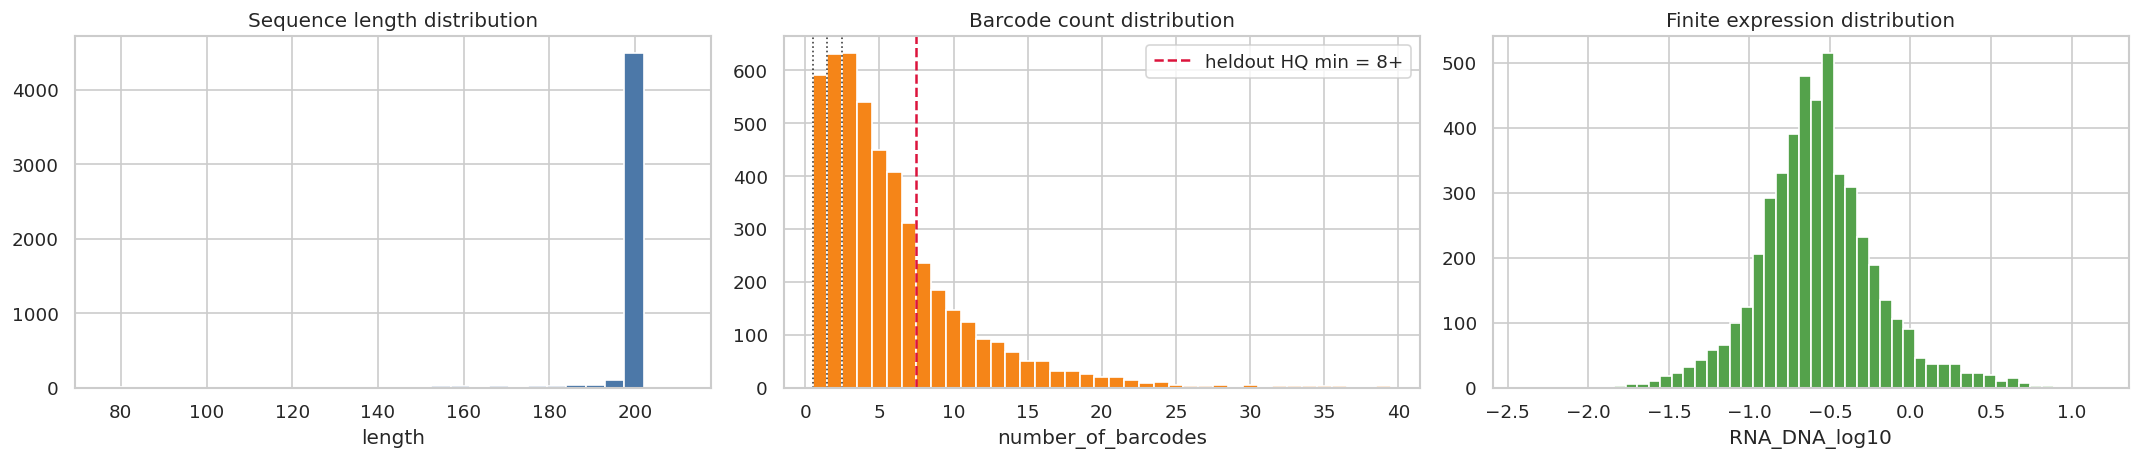

In [5]:
DATA_PATH = Path(example_manifest.get("data_path", ""))
SEQUENCE_COLUMN = example_manifest.get("dataset_sequence_column", "Enhancer")
BARCODE_COLUMN = example_manifest.get("dataset_barcode_column", "number_of_barcodes")
RAW_RATIO_COLUMN = example_manifest.get("dataset_raw_ratio_column", "RNA/DNA")
TARGET_COLUMN = example_manifest.get("modeled_target_column", "RNA_DNA_log10")
HIGH_QUALITY_MIN_BARCODES = int(example_manifest.get("train_priority_min_barcodes", 8))
TRAIN_THRESHOLDS = sorted(pd.to_numeric(runs["train_threshold"], errors="coerce").dropna().astype(int).unique())

raw_df = pd.read_csv(DATA_PATH).copy()
raw_df[BARCODE_COLUMN] = pd.to_numeric(raw_df[BARCODE_COLUMN], errors="coerce")
raw_df["DNA_bc_counts_sum"] = pd.to_numeric(raw_df["DNA_bc_counts_sum"], errors="coerce")
raw_df["RNA_bc_counts_sum"] = pd.to_numeric(raw_df["RNA_bc_counts_sum"], errors="coerce")
raw_df[RAW_RATIO_COLUMN] = pd.to_numeric(raw_df[RAW_RATIO_COLUMN], errors="coerce")
raw_df["RNA_DNA_ratio_from_counts"] = raw_df["RNA_bc_counts_sum"] / raw_df["DNA_bc_counts_sum"]
raw_df[TARGET_COLUMN] = np.log10(raw_df["RNA_DNA_ratio_from_counts"])
raw_df["sequence_len"] = raw_df[SEQUENCE_COLUMN].astype(str).str.len()
raw_df["enhancer_is_acgt_only"] = raw_df[SEQUENCE_COLUMN].astype(str).str.fullmatch(r"[ACGT]+", na=False)

clean_mask = (
    raw_df[SEQUENCE_COLUMN].notna()
    & raw_df["enhancer_is_acgt_only"]
    & raw_df[BARCODE_COLUMN].notna()
    & np.isfinite(raw_df["RNA_DNA_ratio_from_counts"])
    & (raw_df["RNA_DNA_ratio_from_counts"] > 0)
)
clean_df = raw_df.loc[clean_mask].copy().reset_index(drop=True)

summary_df = pd.DataFrame(
    {
        "n_rows_raw": [len(raw_df)],
        "n_rows_clean": [len(clean_df)],
        "n_dropped": [int((~clean_mask).sum())],
        "min_seq_len": [int(clean_df["sequence_len"].min())],
        "median_seq_len": [float(clean_df["sequence_len"].median())],
        "max_seq_len": [int(clean_df["sequence_len"].max())],
        "min_barcodes": [float(clean_df[BARCODE_COLUMN].min())],
        "median_barcodes": [float(clean_df[BARCODE_COLUMN].median())],
        "max_barcodes": [float(clean_df[BARCODE_COLUMN].max())],
        "target_mean": [float(clean_df[TARGET_COLUMN].mean())],
        "target_std": [float(clean_df[TARGET_COLUMN].std())],
    }
)
display(summary_df)

barcode_quantiles = pd.DataFrame({"quantile": [0.50, 0.75, 0.85, 0.90, 0.95, 0.975, 0.99]})
barcode_quantiles["n_barcodes_threshold"] = barcode_quantiles["quantile"].map(
    lambda q: float(clean_df[BARCODE_COLUMN].quantile(q))
)
display(barcode_quantiles)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(clean_df["sequence_len"], bins=30, color="#4C78A8")
axes[0].set_title("Sequence length distribution")
axes[0].set_xlabel("length")

barcode_bins = np.arange(int(clean_df[BARCODE_COLUMN].min()), int(clean_df[BARCODE_COLUMN].max()) + 2) - 0.5
axes[1].hist(clean_df[BARCODE_COLUMN], bins=barcode_bins, color="#F58518")
for threshold in TRAIN_THRESHOLDS:
    axes[1].axvline(threshold - 0.5, color="black", linestyle=":", linewidth=1.0, alpha=0.75)
axes[1].axvline(HIGH_QUALITY_MIN_BARCODES - 0.5, color="crimson", linestyle="--", label=f"heldout HQ min = {HIGH_QUALITY_MIN_BARCODES}+")
axes[1].set_title("Barcode count distribution")
axes[1].set_xlabel(BARCODE_COLUMN)
axes[1].legend()

axes[2].hist(clean_df[TARGET_COLUMN], bins=50, color="#54A24B")
axes[2].set_title("Finite expression distribution")
axes[2].set_xlabel(TARGET_COLUMN)
plt.tight_layout()
plt.show()


,split,pool_role,n_rows,min_barcode,median_barcode,max_barcode,target_mean,target_std
0,test,fixed_test_hq,246,8,11.0,39,-0.585230,0.273923
1,train_rest,train_rest_leftover_hq,737,8,11.0,39,-0.583416,0.283758
2,train_rest,train_rest_lower_quality,3558,1,3.0,7,-0.567617,0.389883
3,val,fixed_val_hq,246,8,11.0,34,-0.557057,0.264826


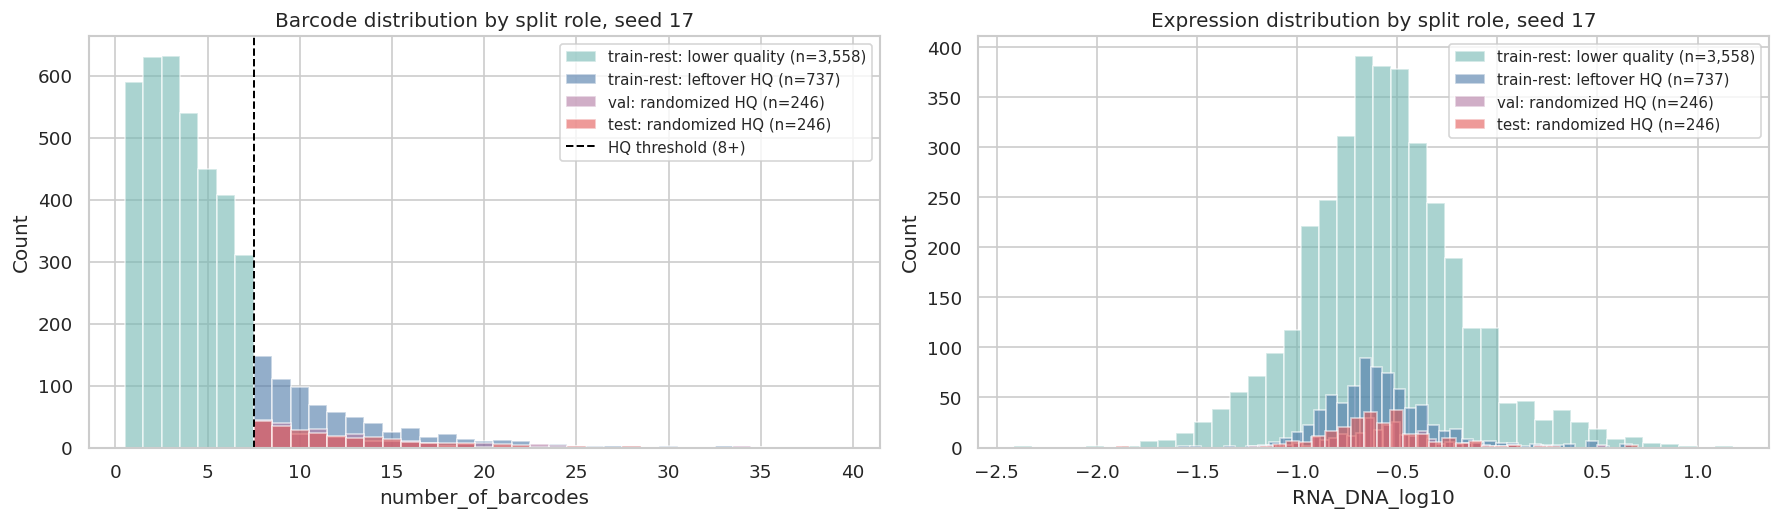

In [6]:
SPLIT_SEED_TO_SHOW = int(sorted(split_rows["seed"].dropna().unique())[0])
viz_df = split_rows[split_rows["seed"] == SPLIT_SEED_TO_SHOW].copy()
viz_df[BARCODE_COLUMN] = pd.to_numeric(viz_df[BARCODE_COLUMN], errors="coerce")
viz_df[TARGET_COLUMN] = pd.to_numeric(viz_df[TARGET_COLUMN], errors="coerce")

split_role_summary = (
    viz_df.groupby(["split", "pool_role"], observed=True)
    .agg(
        n_rows=("row_id", "size"),
        min_barcode=(BARCODE_COLUMN, "min"),
        median_barcode=(BARCODE_COLUMN, "median"),
        max_barcode=(BARCODE_COLUMN, "max"),
        target_mean=(TARGET_COLUMN, "mean"),
        target_std=(TARGET_COLUMN, "std"),
    )
    .reset_index()
)
display(split_role_summary)

plot_order = ["train_rest_lower_quality", "train_rest_leftover_hq", "fixed_val_hq", "fixed_test_hq"]
labels = {
    "train_rest_leftover_hq": "train-rest: leftover HQ",
    "train_rest_lower_quality": "train-rest: lower quality",
    "fixed_val_hq": "val: randomized HQ",
    "fixed_test_hq": "test: randomized HQ",
}
role_counts = viz_df["pool_role"].value_counts().to_dict()

def label_with_n(pool_role: str) -> str:
    return f"{labels[pool_role]} (n={int(role_counts.get(pool_role, 0)):,})"

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
barcode_bins = np.arange(int(viz_df[BARCODE_COLUMN].min()), int(viz_df[BARCODE_COLUMN].max()) + 2) - 0.5
for key in plot_order:
    subset = viz_df[viz_df["pool_role"] == key]
    if subset.empty:
        continue
    axes[0].hist(
        subset[BARCODE_COLUMN],
        bins=barcode_bins,
        alpha=0.60,
        label=label_with_n(key),
        color=POOL_ROLE_PALETTE.get(key),
    )
axes[0].axvline(HIGH_QUALITY_MIN_BARCODES - 0.5, color="black", linestyle="--", linewidth=1.2, label=f"HQ threshold ({HIGH_QUALITY_MIN_BARCODES}+)")
axes[0].set_title(f"Barcode distribution by split role, seed {SPLIT_SEED_TO_SHOW}")
axes[0].set_xlabel(BARCODE_COLUMN)
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

for key in plot_order:
    subset = viz_df[viz_df["pool_role"] == key]
    if subset.empty:
        continue
    axes[1].hist(
        subset[TARGET_COLUMN],
        bins=40,
        alpha=0.60,
        label=label_with_n(key),
        color=POOL_ROLE_PALETTE.get(key),
    )
axes[1].set_title(f"Expression distribution by split role, seed {SPLIT_SEED_TO_SHOW}")
axes[1].set_xlabel(TARGET_COLUMN)
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


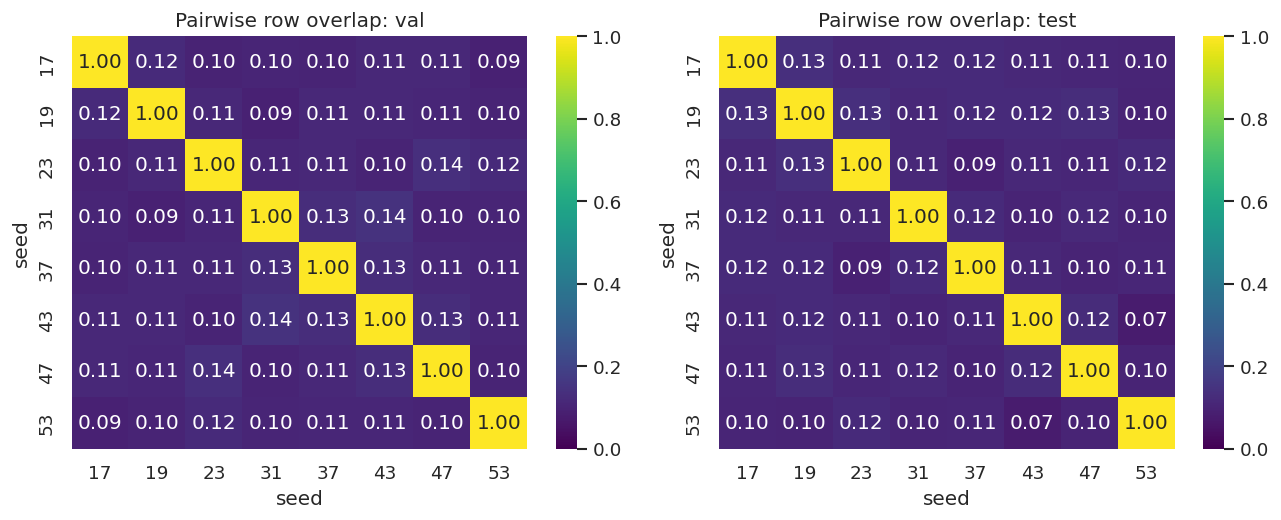

In [7]:
def pairwise_jaccard_by_seed(frame: pd.DataFrame, *, split_name: str) -> pd.DataFrame:
    sets = {
        int(seed): set(group["row_id"].astype(int))
        for seed, group in frame[frame["split"] == split_name].groupby("seed")
    }
    seeds = sorted(sets)
    mat = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
    for a in seeds:
        for b in seeds:
            denom = len(sets[a] | sets[b])
            mat.loc[a, b] = len(sets[a] & sets[b]) / denom if denom else np.nan
    return mat


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, split_name in zip(axes, ["val", "test"]):
    mat = pairwise_jaccard_by_seed(split_rows, split_name=split_name)
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"Pairwise row overlap: {split_name}")
    ax.set_xlabel("seed")
    ax.set_ylabel("seed")
plt.tight_layout()
plt.show()


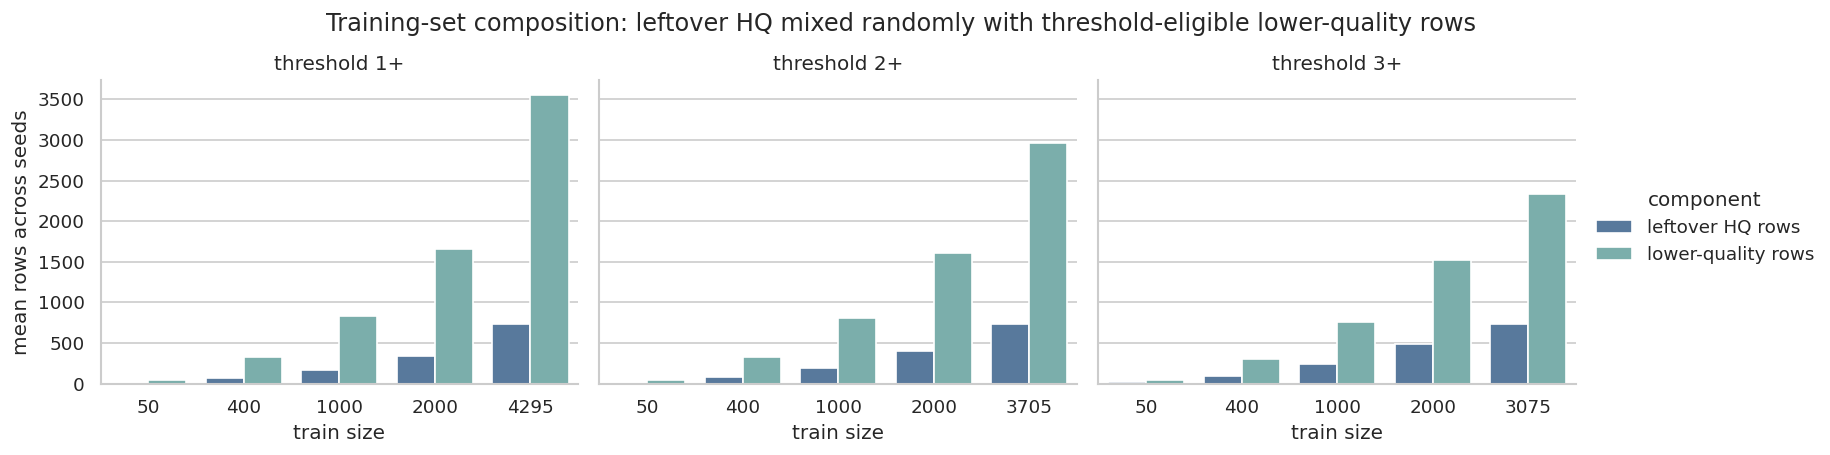

In [8]:
composition = planned_size_summary.copy()
composition_long = composition.melt(
    id_vars=["train_threshold", "threshold_label", "train_size", "train_fraction_mean", "is_full_pool"],
    value_vars=["train_hq_mean", "train_lq_mean"],
    var_name="component",
    value_name="mean_rows",
)
component_labels = {"train_hq_mean": "leftover HQ rows", "train_lq_mean": "lower-quality rows"}
composition_long["component"] = composition_long["component"].map(component_labels)

g = sns.catplot(
    data=composition_long,
    x="train_size",
    y="mean_rows",
    hue="component",
    col="threshold_label",
    kind="bar",
    height=3.6,
    aspect=1.25,
    sharex=False,
    palette=["#4C78A8", "#72B7B2"],
)
g.set_axis_labels("train size", "mean rows across seeds")
g.set_titles("threshold {col_name}")
g.fig.suptitle("Training-set composition: leftover HQ mixed randomly with threshold-eligible lower-quality rows", y=1.05)
plt.show()


## Metric Helpers

In [9]:
def standard_error(values) -> float:
    arr = pd.to_numeric(pd.Series(values), errors="coerce").dropna().astype(float)
    if len(arr) <= 1:
        return np.nan
    return float(arr.std(ddof=1) / math.sqrt(len(arr)))


def finite_numeric_values(values, *, positive_only=False) -> np.ndarray:
    numeric = pd.to_numeric(pd.Series(values), errors="coerce")
    mask = np.isfinite(numeric)
    if positive_only:
        mask &= numeric > 0
    return numeric.loc[mask].astype(float).to_numpy()


def apply_log10_xaxis(ax, values) -> None:
    x_values = finite_numeric_values(values, positive_only=True)
    if len(x_values) == 0:
        return
    ax.set_xscale("log", base=10)
    if x_values.min() != x_values.max():
        ax.set_xlim(x_values.min() / 1.08, x_values.max() * 1.08)
    min_power = int(np.floor(np.log10(x_values.min())))
    max_power = int(np.ceil(np.log10(x_values.max())))
    ax.set_xticks(10.0 ** np.arange(min_power, max_power + 1))
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def make_metric_long(frame: pd.DataFrame, *, specs=METRIC_SPECS, split_values=SPLIT_ORDER) -> pd.DataFrame:
    id_cols = [
        "run_id",
        "seed",
        "split_strategy",
        "split_pool",
        "split_seed_effective",
        "val_seed_effective",
        "test_seed_effective",
        "target_scaler_mean",
        "target_scaler_std",
        "setting",
        "init_head",
        "head_idx",
        "unfreeze_scope",
        "train_threshold",
        "threshold_label",
        "train_size",
        "train_fraction",
        "train_pool_eligible_size",
        "train_pool_leftover_hq_size",
        "train_pool_lower_quality_size",
        "train_hq_count",
        "train_lower_quality_count",
        "train_hq_fraction",
        "val_size",
        "test_size",
        "head_lr",
        "backbone_lr",
        "best_epoch",
        "final_trainable_params",
        "source_seed_dir",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    rows = []
    for metric_root, spec in specs.items():
        for split in split_values:
            col = spec["cols"].get(split)
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part["split"] = split
            part["metric_root"] = metric_root
            part["metric_label"] = spec["label"]
            part["higher_is_better"] = spec["higher_is_better"]
            part["source_column"] = col
            part["value"] = pd.to_numeric(frame[col], errors="coerce").to_numpy()
            rows.append(part)
    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not out.empty:
        out["unfreeze_scope"] = pd.Categorical(out["unfreeze_scope"], categories=UNFREEZE_SCOPE_ORDER, ordered=True)
        out["init_head"] = pd.Categorical(out["init_head"], categories=HEAD_ORDER, ordered=True)
    return out


def make_epoch_metric_long(frame: pd.DataFrame, *, specs=HISTORY_METRIC_SPECS, split_values=SPLIT_ORDER) -> pd.DataFrame:
    id_cols = [
        "run_id",
        "seed",
        "epoch",
        "setting",
        "init_head",
        "head_idx",
        "unfreeze_scope",
        "train_threshold",
        "threshold_label",
        "train_size",
        "train_fraction",
        "split_seed_effective",
        "val_seed_effective",
        "test_seed_effective",
        "head_lr",
        "backbone_lr",
        "source_seed_dir",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    rows = []
    for metric_root, spec in specs.items():
        for split in split_values:
            col = spec["cols"].get(split)
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part["split"] = split
            part["metric_root"] = metric_root
            part["metric_label"] = spec["label"]
            part["higher_is_better"] = spec["higher_is_better"]
            part["source_column"] = col
            part["value"] = pd.to_numeric(frame[col], errors="coerce").to_numpy()
            rows.append(part)
    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not out.empty:
        out["unfreeze_scope"] = pd.Categorical(out["unfreeze_scope"], categories=UNFREEZE_SCOPE_ORDER, ordered=True)
        out["init_head"] = pd.Categorical(out["init_head"], categories=HEAD_ORDER, ordered=True)
    return out


run_long = make_metric_long(runs)
history_long = make_epoch_metric_long(histories)
print("run_long:", run_long.shape)
print("history_long:", history_long.shape)


run_long: (12960, 36)
history_long: (736500, 23)


In [10]:
CONFIG_COLS = [
    "setting",
    "init_head",
    "unfreeze_scope",
    "train_threshold",
    "threshold_label",
    "train_size",
    "train_fraction",
    "train_pool_eligible_size",
    "head_lr",
    "backbone_lr",
]

metric_cols = [
    "train_r2_cod",
    "val_r2_cod",
    "test_r2_cod",
    "train_pearson",
    "val_pearson",
    "test_pearson",
    "train_spearman",
    "val_spearman",
    "test_spearman",
    "train_loss_standardized",
    "val_loss_standardized",
    "test_loss_standardized",
    "best_epoch",
]
metric_cols = [col for col in metric_cols if col in runs.columns]

agg_dict = {}
for col in metric_cols:
    agg_dict[f"{col}_mean"] = (col, "mean")
    agg_dict[f"{col}_std"] = (col, "std")
    agg_dict[f"{col}_se"] = (col, standard_error)
    agg_dict[f"{col}_count"] = (col, "count")

perf_summary = (
    runs.groupby(CONFIG_COLS, observed=True)
    .agg(**agg_dict)
    .reset_index()
    .sort_values(["train_threshold", "train_size", "init_head", "unfreeze_scope"])
)
perf_summary["is_full_pool"] = perf_summary["train_size"] == perf_summary["train_pool_eligible_size"]
print("perf_summary:", perf_summary.shape)

top_by_val = perf_summary.sort_values("val_pearson_mean", ascending=False).head(20)
top_by_test = perf_summary.sort_values("test_pearson_mean", ascending=False).head(20)

display(Markdown("Top 20 configs by mean validation Pearson. Use this for HPO selection."))
display(top_by_val[["train_threshold", "train_size", "is_full_pool", "init_head", "unfreeze_scope", "val_pearson_mean", "val_pearson_se", "test_pearson_mean", "test_pearson_se", "test_r2_cod_mean", "best_epoch_mean"]])

display(Markdown("Top 20 configs by mean test Pearson. Diagnostic only, not a selection rule."))
display(top_by_test[["train_threshold", "train_size", "is_full_pool", "init_head", "unfreeze_scope", "val_pearson_mean", "test_pearson_mean", "test_pearson_se", "test_r2_cod_mean", "best_epoch_mean"]])


perf_summary: (135, 63)


Top 20 configs by mean validation Pearson. Use this for HPO selection.

,train_threshold,train_size,is_full_pool,init_head,unfreeze_scope,val_pearson_mean,val_pearson_se,test_pearson_mean,test_pearson_se,test_r2_cod_mean,best_epoch_mean
79,1,4295,True,HepG2,full,0.514367,0.009504,0.506604,0.022853,0.233702,3.000
34,1,4295,True,K562,full,0.511005,0.012496,0.502483,0.024398,0.233864,2.875
44,3,3075,True,K562,full,0.507129,0.012706,0.482846,0.025960,0.203705,2.750
124,1,4295,True,SKNSH,full,0.505763,0.015806,0.490399,0.023979,0.225314,2.750
84,2,3705,True,HepG2,full,0.504531,0.007333,0.491205,0.020461,0.208850,2.750
19,1,4295,True,K562,conv3_plus,0.504497,0.010546,0.486818,0.027722,0.226120,4.000
64,1,4295,True,HepG2,conv3_plus,0.504212,0.010159,0.491741,0.026944,0.230611,3.875
39,2,3705,True,K562,full,0.503490,0.012007,0.490520,0.024584,0.214592,2.750
69,2,3705,True,HepG2,conv3_plus,0.502713,0.007981,0.479378,0.024230,0.206591,4.625
134,3,3075,True,SKNSH,full,0.502049,0.009661,0.480394,0.023581,0.201715,3.000


Top 20 configs by mean test Pearson. Diagnostic only, not a selection rule.

,train_threshold,train_size,is_full_pool,init_head,unfreeze_scope,val_pearson_mean,test_pearson_mean,test_pearson_se,test_r2_cod_mean,best_epoch_mean
79,1,4295,True,HepG2,full,0.514367,0.506604,0.022853,0.233702,3.000
34,1,4295,True,K562,full,0.511005,0.502483,0.024398,0.233864,2.875
64,1,4295,True,HepG2,conv3_plus,0.504212,0.491741,0.026944,0.230611,3.875
84,2,3705,True,HepG2,full,0.504531,0.491205,0.020461,0.208850,2.750
39,2,3705,True,K562,full,0.503490,0.490520,0.024584,0.214592,2.750
124,1,4295,True,SKNSH,full,0.505763,0.490399,0.023979,0.225314,2.750
19,1,4295,True,K562,conv3_plus,0.504497,0.486818,0.027722,0.226120,4.000
129,2,3705,True,SKNSH,full,0.501702,0.484116,0.023474,0.210442,2.875
89,3,3075,True,HepG2,full,0.500266,0.483281,0.022955,0.198628,3.250
44,3,3075,True,K562,full,0.507129,0.482846,0.025960,0.203705,2.750


## Learning Curves

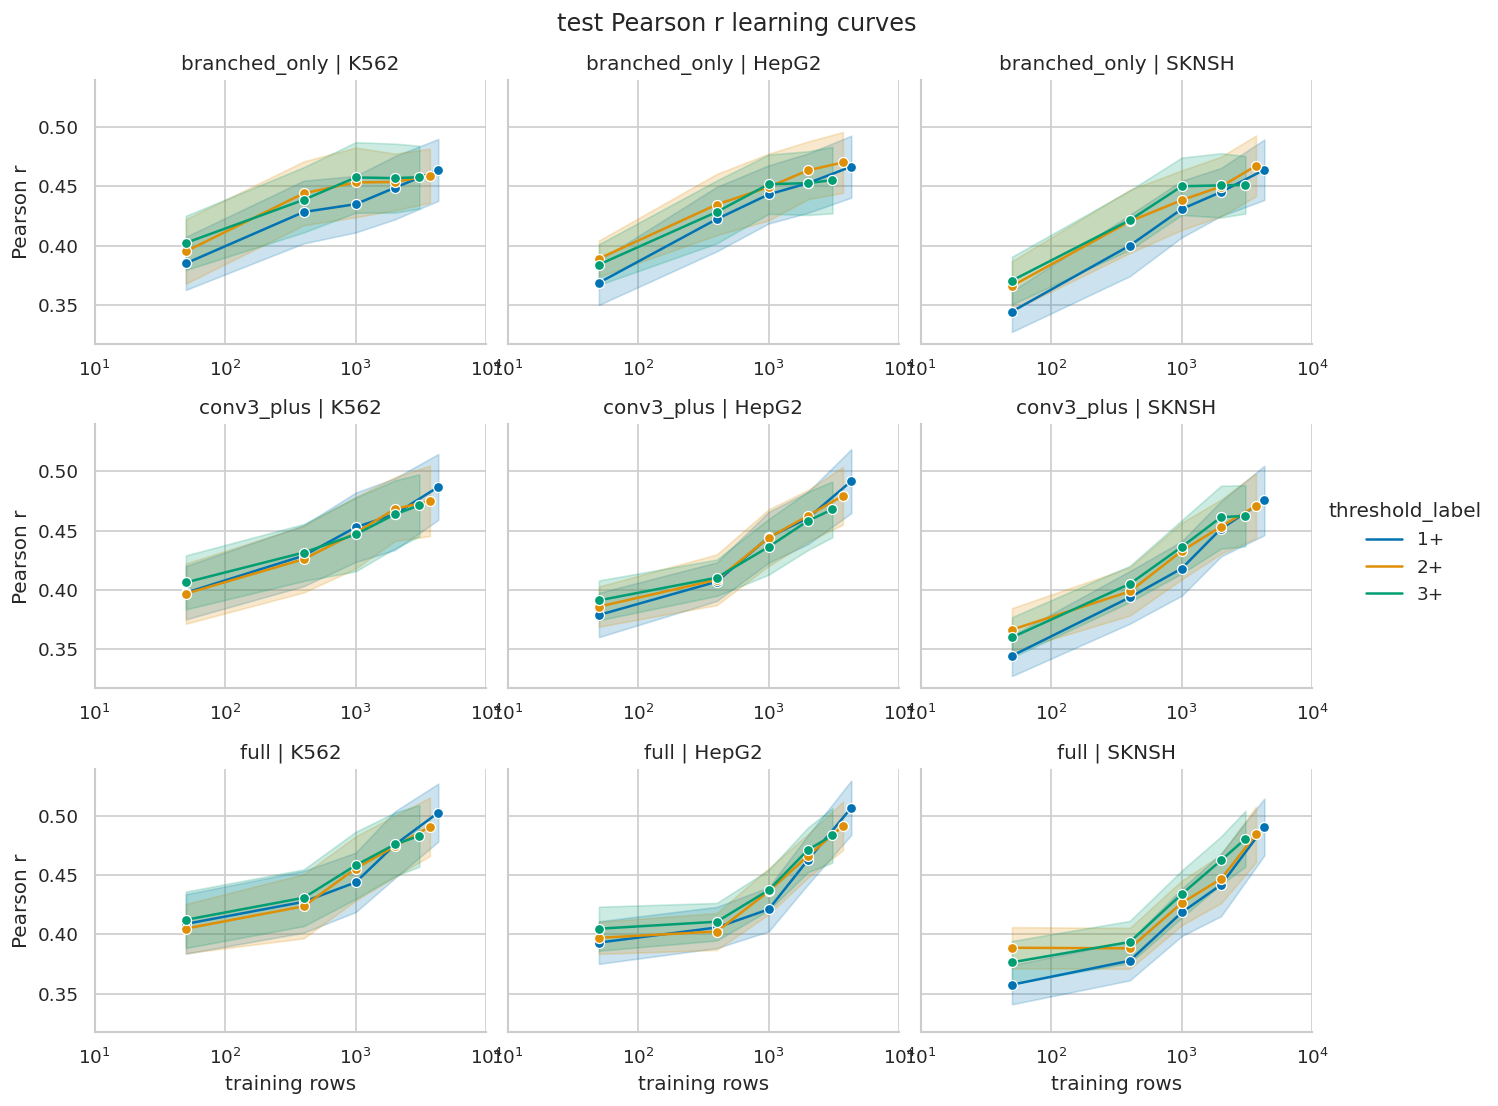

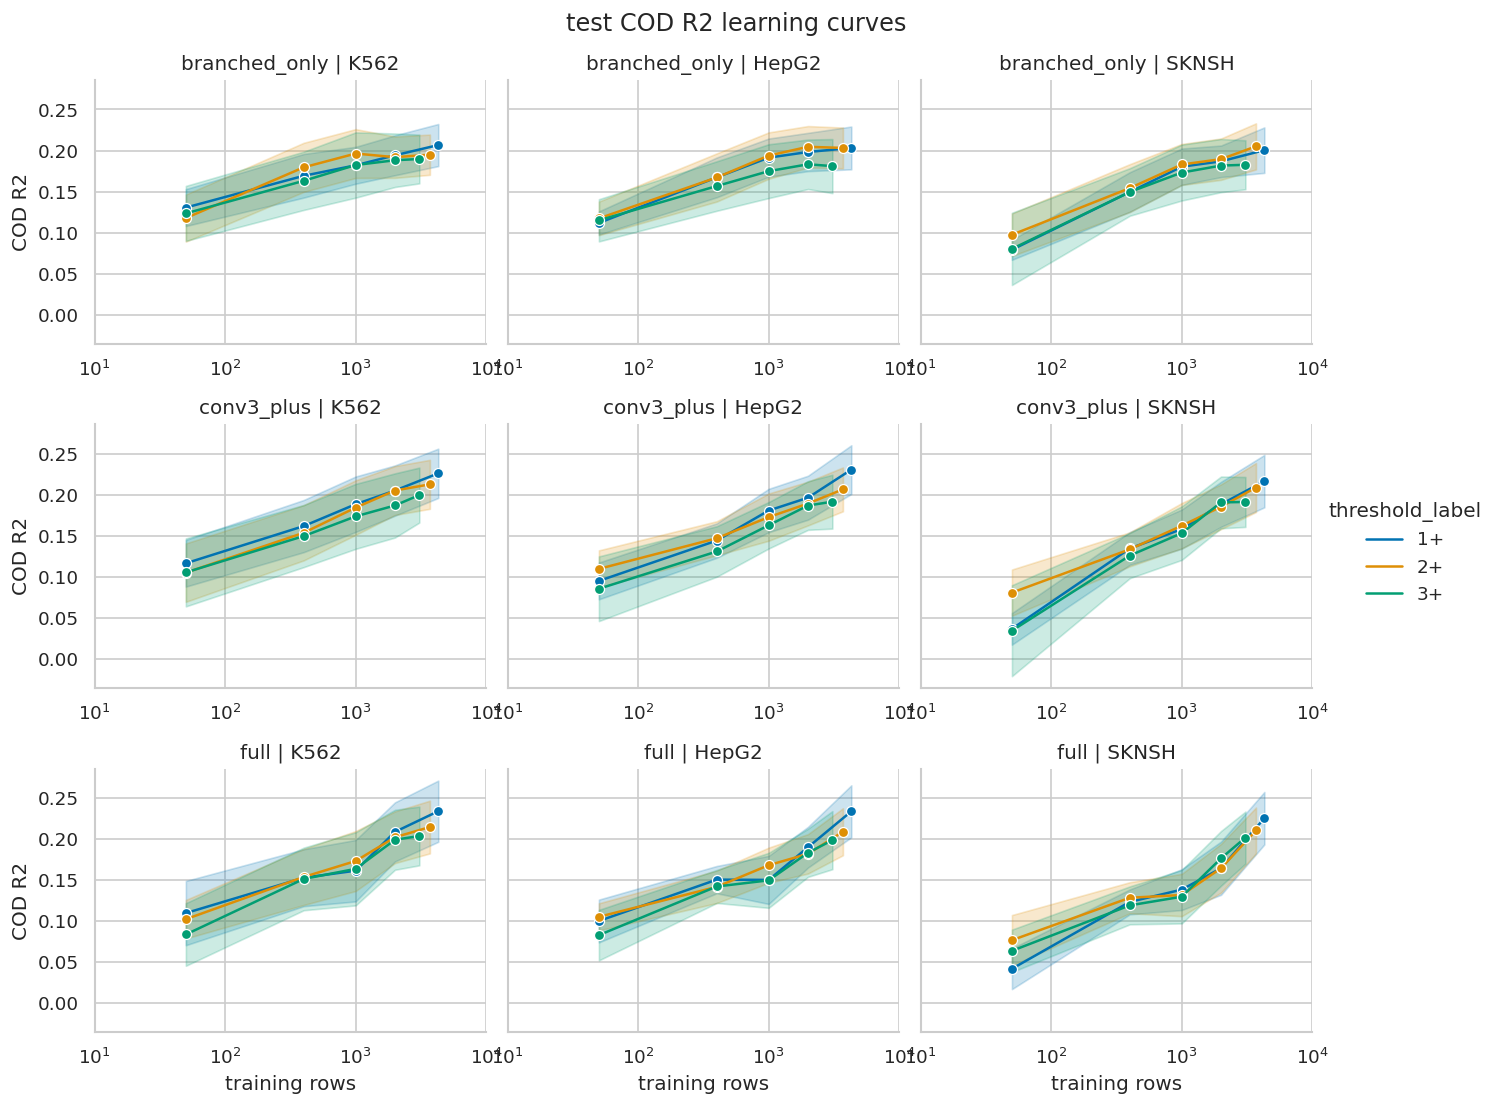

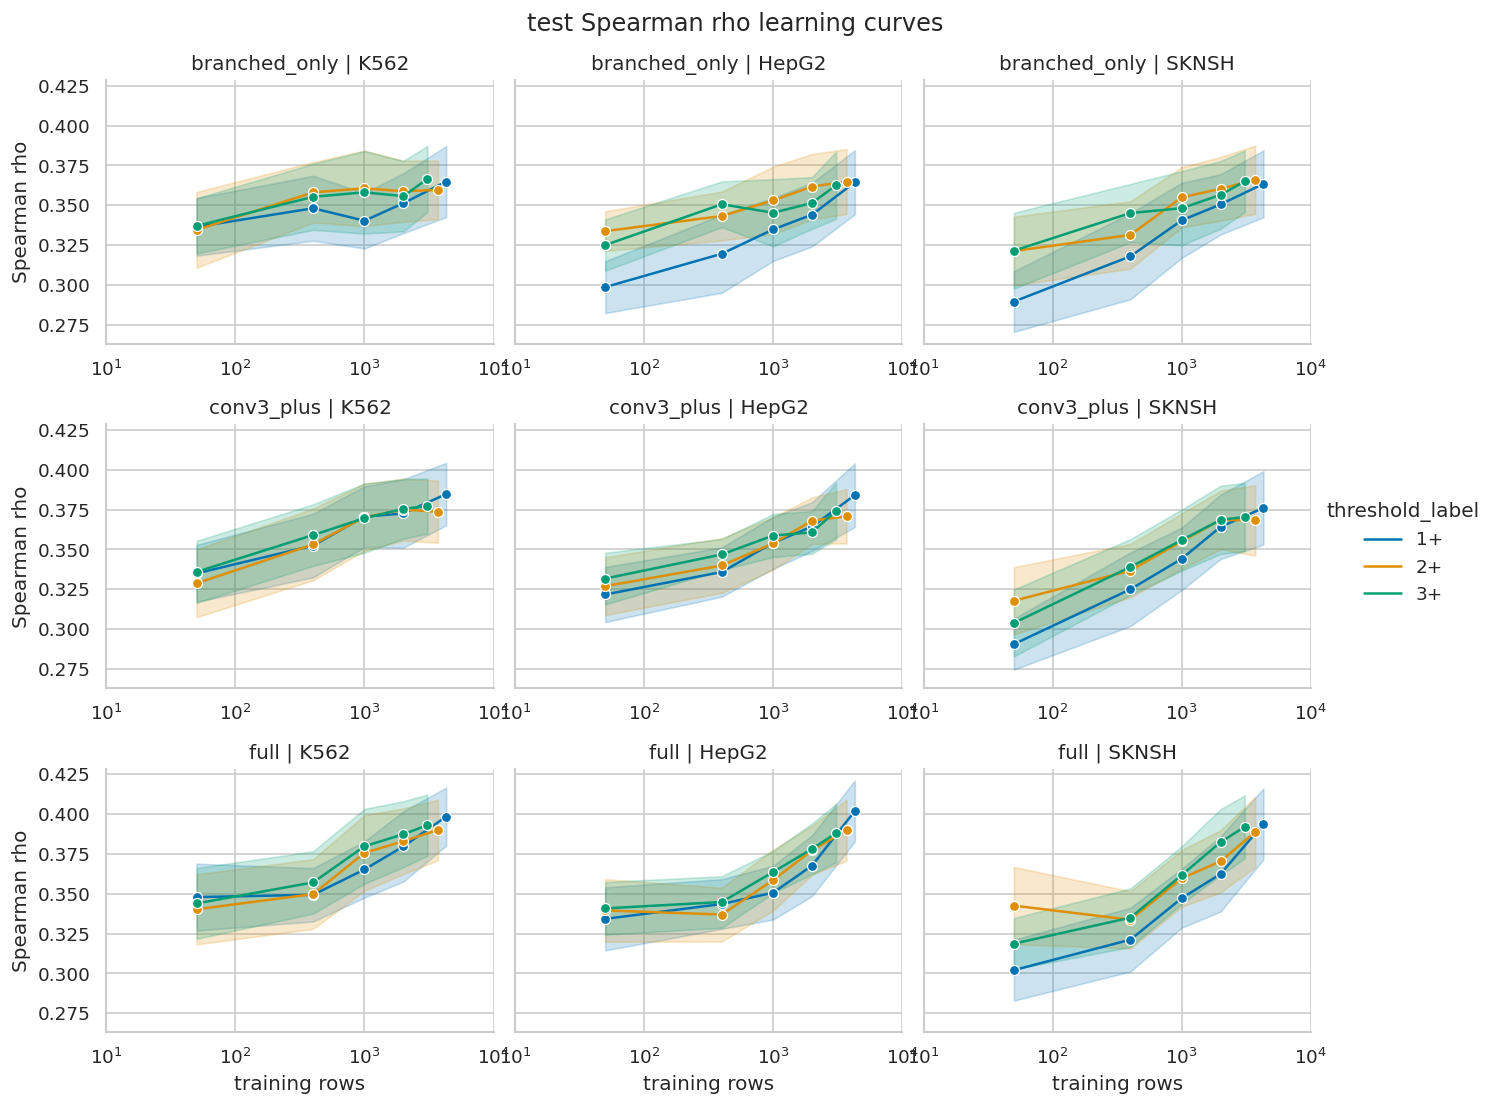

In [11]:
def plot_metric_learning_curves(
    frame_long: pd.DataFrame,
    *,
    metric_root: str = "pearson",
    split: str = "test",
    row: str = "unfreeze_scope",
    col: str = "init_head",
    hue: str = "threshold_label",
    log_x: bool = True,
    height: float = 3.0,
    aspect: float = 1.25,
):
    plot_df = frame_long[
        (frame_long["metric_root"] == metric_root)
        & (frame_long["split"] == split)
        & np.isfinite(frame_long["value"])
    ].copy()
    if plot_df.empty:
        raise ValueError("No rows after filtering.")
    plot_df["threshold_label"] = pd.Categorical(
        plot_df["threshold_label"],
        categories=[f"{x}+" for x in THRESHOLD_ORDER],
        ordered=True,
    )
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue=hue,
        row=row,
        col=col,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=height,
        aspect=aspect,
        facet_kws={"sharex": False, "sharey": True},
    )
    if log_x:
        for ax in g.axes.flat:
            apply_log10_xaxis(ax, plot_df["train_size"])
    g.set_axis_labels("training rows", METRIC_SPECS[metric_root]["label"])
    g.set_titles("{row_name} | {col_name}")
    g.fig.suptitle(f"{split} {METRIC_SPECS[metric_root]['label']} learning curves", y=1.02)
    return g


for metric_root in ["pearson", "cod_r2", "spearman"]:
    g = plot_metric_learning_curves(run_long, metric_root=metric_root, split="test")
    plt.show()


### Scope-Level Threshold Learning Curve

This reproduces the earlier `finetune_learning_curve_sweep` view: facet by unfreeze scope, color by training-threshold pool, and average over cell-type heads, seeds, and any repeated HPO settings at each plotted point. The shared-size points isolate pool composition at fixed `n`; the full-pool endpoint is intentionally not matched because each threshold has a different eligible pool size.


Averaging unit: all rows with the same `unfreeze_scope`, `threshold_label`, and `train_size`; this averages across cell-type heads, seeds, and repeated LR settings.

,unfreeze_scope,threshold_label,train_size,test_pearson_mean,test_pearson_se,n_rows,n_seeds,n_heads,n_head_lrs,n_backbone_lrs
0,branched_only,1+,50,0.366161,0.011315,24,8,3,1,1
1,branched_only,1+,400,0.417012,0.014830,24,8,3,1,1
2,branched_only,1+,1000,0.436390,0.013316,24,8,3,1,1
3,branched_only,1+,2000,0.448975,0.013323,24,8,3,1,1
4,branched_only,1+,4295,0.464865,0.014269,24,8,3,1,1
5,branched_only,2+,50,0.383506,0.012225,24,8,3,1,1
6,branched_only,2+,400,0.433140,0.014719,24,8,3,1,1
7,branched_only,2+,1000,0.447066,0.015268,24,8,3,1,1
8,branched_only,2+,2000,0.455713,0.013544,24,8,3,1,1
9,branched_only,2+,3705,0.465506,0.013650,24,8,3,1,1


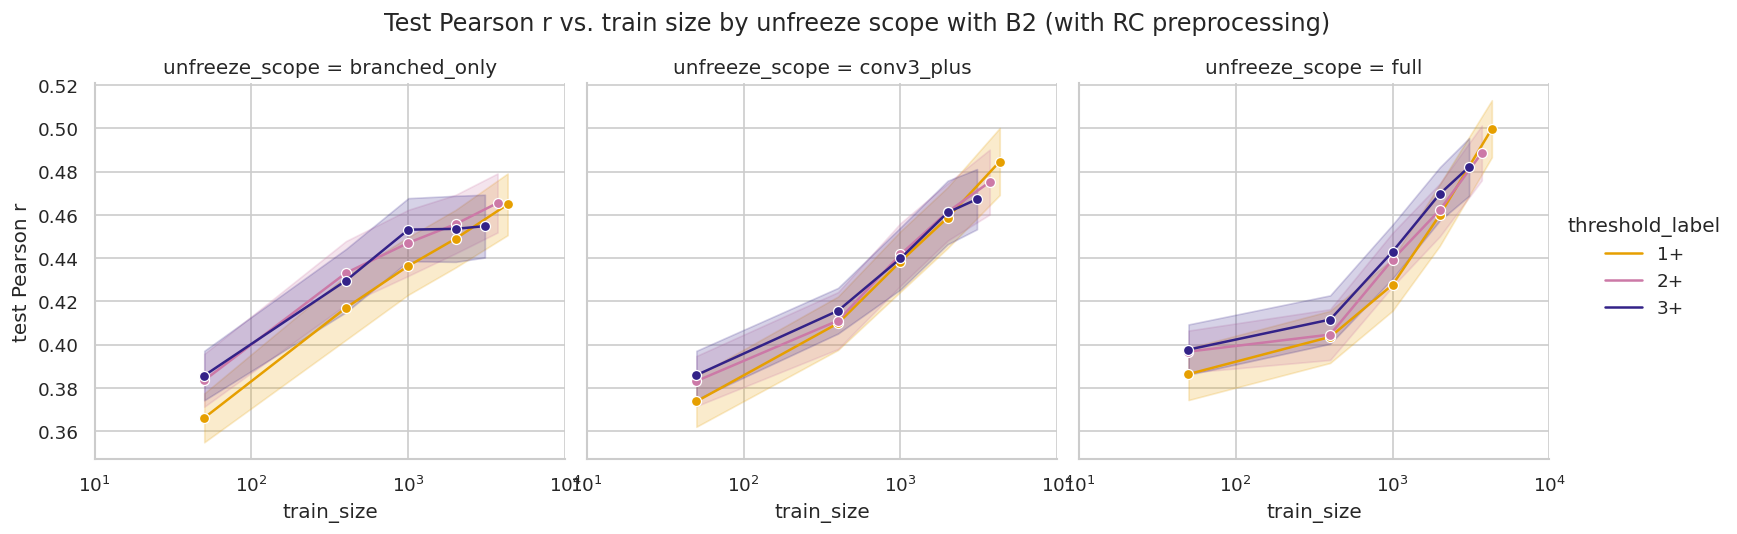

In [12]:
TOP_SCOPE_ORDER = ["head_only", "branched_only", "linear_all_head", "conv3_plus", "full"]
SCOPE_THRESHOLD_PLOT_SETTING = "B2_with_RC"
SCOPE_THRESHOLD_METRIC = "pearson"
SCOPE_THRESHOLD_SPLIT = "test"

scope_threshold_curve = run_long[
    (run_long["metric_root"] == SCOPE_THRESHOLD_METRIC)
    & (run_long["split"] == SCOPE_THRESHOLD_SPLIT)
    & np.isfinite(run_long["value"])
].copy()

if "setting" in scope_threshold_curve.columns:
    available_settings = set(scope_threshold_curve["setting"].dropna().astype(str))
    if SCOPE_THRESHOLD_PLOT_SETTING in available_settings:
        scope_threshold_curve = scope_threshold_curve[
            scope_threshold_curve["setting"].astype(str) == SCOPE_THRESHOLD_PLOT_SETTING
        ].copy()

available_scopes = set(scope_threshold_curve["unfreeze_scope"].dropna().astype(str))
available_scope_order = [scope for scope in TOP_SCOPE_ORDER if scope in available_scopes]
if not available_scope_order:
    available_scope_order = [scope for scope in UNFREEZE_SCOPE_ORDER if scope in available_scopes]
if not available_scope_order:
    raise ValueError("No unfreeze scopes are available for the scope-threshold learning curve.")

threshold_label_order = [f"{x}+" for x in THRESHOLD_ORDER]
threshold_palette = {"1+": "#E69F00", "2+": "#CC79A7", "3+": "#332288"}

scope_threshold_curve = scope_threshold_curve[
    scope_threshold_curve["unfreeze_scope"].astype(str).isin(available_scope_order)
].copy()
scope_threshold_curve["unfreeze_scope"] = pd.Categorical(
    scope_threshold_curve["unfreeze_scope"].astype(str),
    categories=available_scope_order,
    ordered=True,
)
scope_threshold_curve["threshold_label"] = pd.Categorical(
    scope_threshold_curve["threshold_label"],
    categories=threshold_label_order,
    ordered=True,
)

scope_threshold_curve_summary = (
    scope_threshold_curve.groupby(["unfreeze_scope", "threshold_label", "train_size"], observed=True)
    .agg(
        test_pearson_mean=("value", "mean"),
        test_pearson_se=("value", standard_error),
        n_rows=("value", "size"),
        n_seeds=("seed", "nunique"),
        n_heads=("init_head", "nunique"),
        n_head_lrs=("head_lr", "nunique"),
        n_backbone_lrs=("backbone_lr", "nunique"),
    )
    .reset_index()
    .sort_values(["unfreeze_scope", "threshold_label", "train_size"])
)

display(Markdown(
    "Averaging unit: all rows with the same `unfreeze_scope`, `threshold_label`, and `train_size`; "
    "this averages across cell-type heads, seeds, and repeated LR settings."
))
display(scope_threshold_curve_summary)

metric_label = METRIC_SPECS[SCOPE_THRESHOLD_METRIC]["label"]
title_setting = "B2 (with RC preprocessing)" if SCOPE_THRESHOLD_PLOT_SETTING == "B2_with_RC" else SCOPE_THRESHOLD_PLOT_SETTING

g = sns.relplot(
    data=scope_threshold_curve,
    x="train_size",
    y="value",
    hue="threshold_label",
    hue_order=threshold_label_order,
    col="unfreeze_scope",
    col_order=available_scope_order,
    kind="line",
    marker="o",
    estimator="mean",
    errorbar="se",
    height=4.2,
    aspect=1.05,
    palette=threshold_palette,
    facet_kws={"sharey": True, "sharex": True},
)
for ax in g.axes.flat:
    apply_log10_xaxis(ax, scope_threshold_curve["train_size"])
g.set_axis_labels("train_size", f"{SCOPE_THRESHOLD_SPLIT} {metric_label}")
g.set_titles("unfreeze_scope = {col_name}")
g.fig.suptitle(f"Test Pearson r vs. train size by unfreeze scope with {title_setting}", y=1.05)
plt.show()


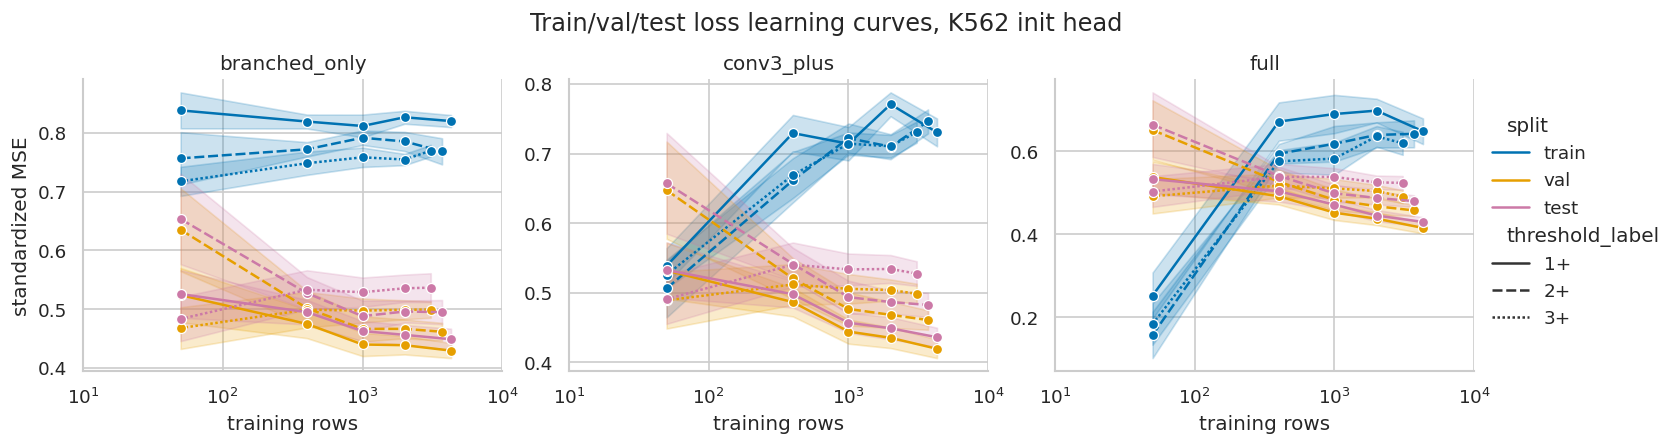

In [13]:
loss_plot = run_long[(run_long["metric_root"] == "loss") & (run_long["split"].isin(["train", "val", "test"]))].copy()
loss_plot = loss_plot[loss_plot["init_head"] == "K562"]

g = sns.relplot(
    data=loss_plot,
    x="train_size",
    y="value",
    hue="split",
    style="threshold_label",
    col="unfreeze_scope",
    kind="line",
    marker="o",
    estimator="mean",
    errorbar="se",
    height=3.5,
    aspect=1.2,
    palette=SPLIT_PALETTE,
    facet_kws={"sharex": False, "sharey": False},
)
for ax in g.axes.flat:
    apply_log10_xaxis(ax, loss_plot["train_size"])
g.set_axis_labels("training rows", "standardized MSE")
g.set_titles("{col_name}")
g.fig.suptitle("Train/val/test loss learning curves, K562 init head", y=1.05)
plt.show()


## Matched-Size and Full-Pool Comparisons

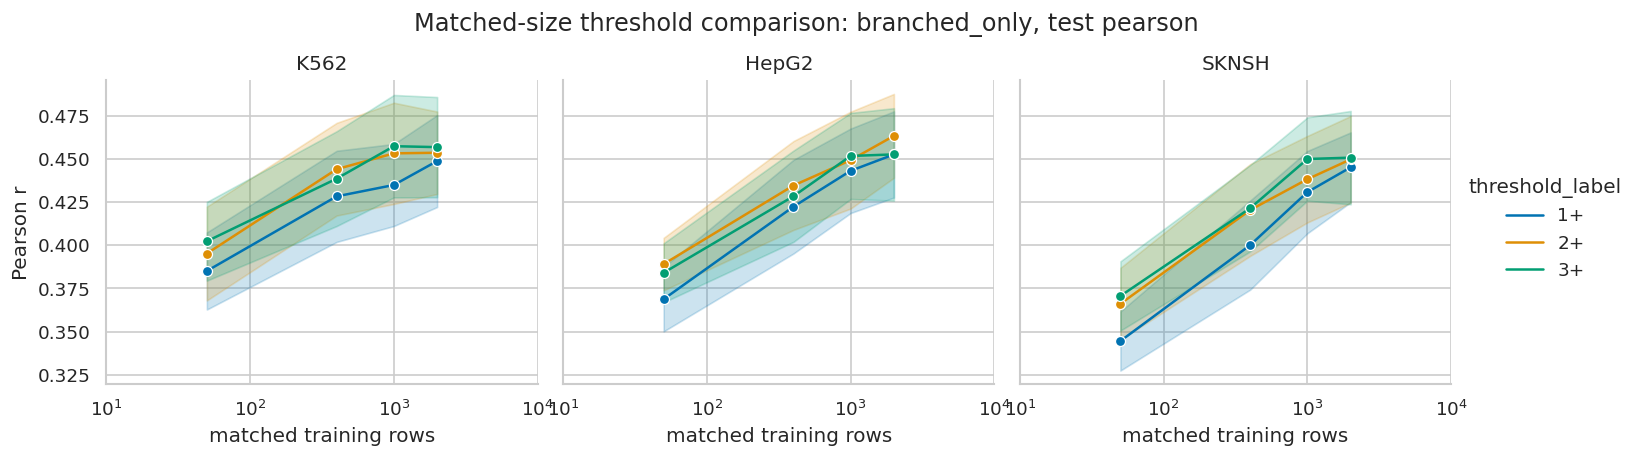

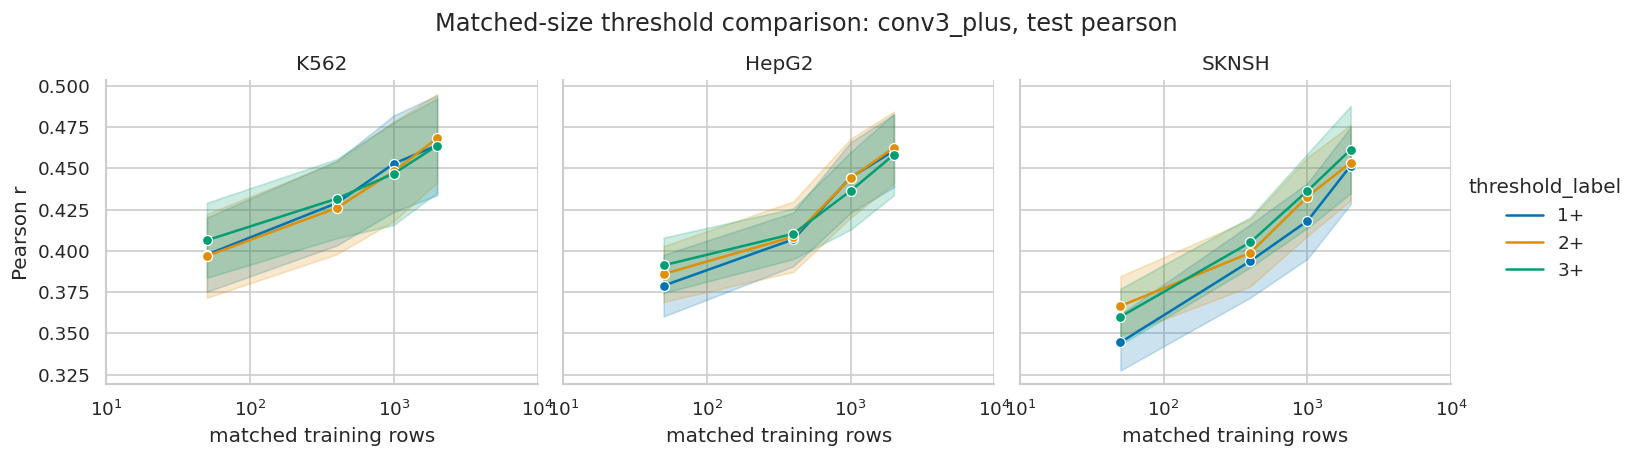

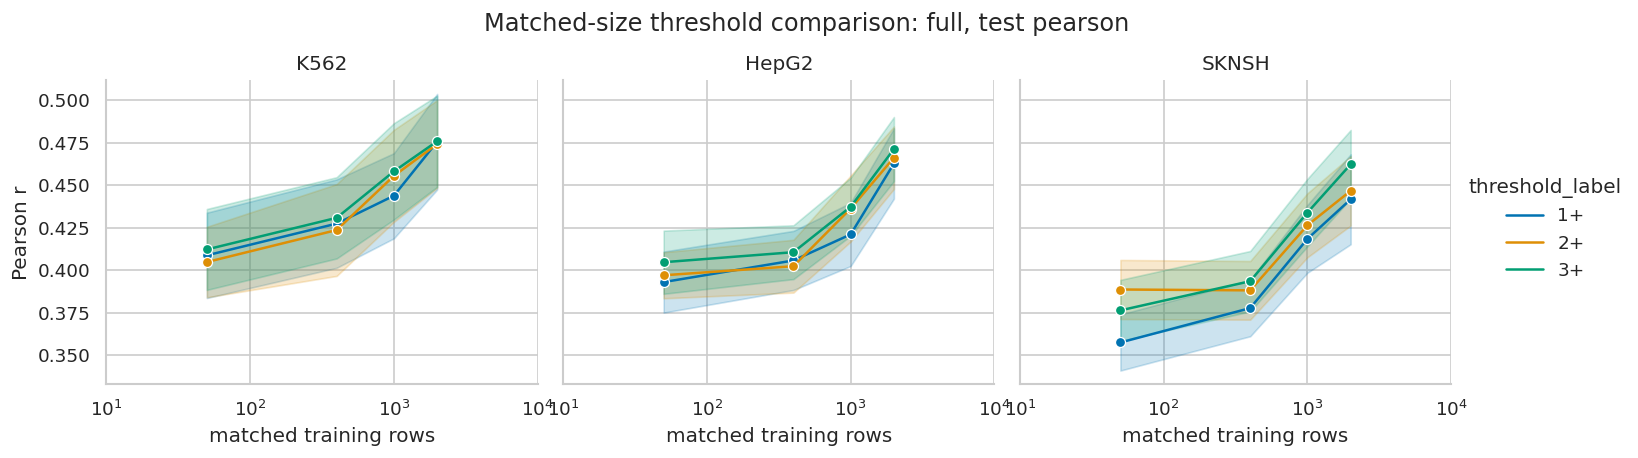

In [14]:
MATCHED_SIZES = [50, 400, 1000, 2000]
matched = run_long[
    (run_long["metric_root"] == PRIMARY_METRIC_ROOT)
    & (run_long["split"] == PRIMARY_SPLIT)
    & (run_long["train_size"].isin(MATCHED_SIZES))
].copy()

for scope in UNFREEZE_SCOPE_ORDER:
    sub = matched[matched["unfreeze_scope"] == scope]
    if sub.empty:
        continue
    g = sns.relplot(
        data=sub,
        x="train_size",
        y="value",
        hue="threshold_label",
        col="init_head",
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.6,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": True},
    )
    for ax in g.axes.flat:
        apply_log10_xaxis(ax, sub["train_size"])
    g.set_axis_labels("matched training rows", METRIC_SPECS[PRIMARY_METRIC_ROOT]["label"])
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Matched-size threshold comparison: {scope}, {PRIMARY_SPLIT} {PRIMARY_METRIC_ROOT}", y=1.05)
    plt.show()


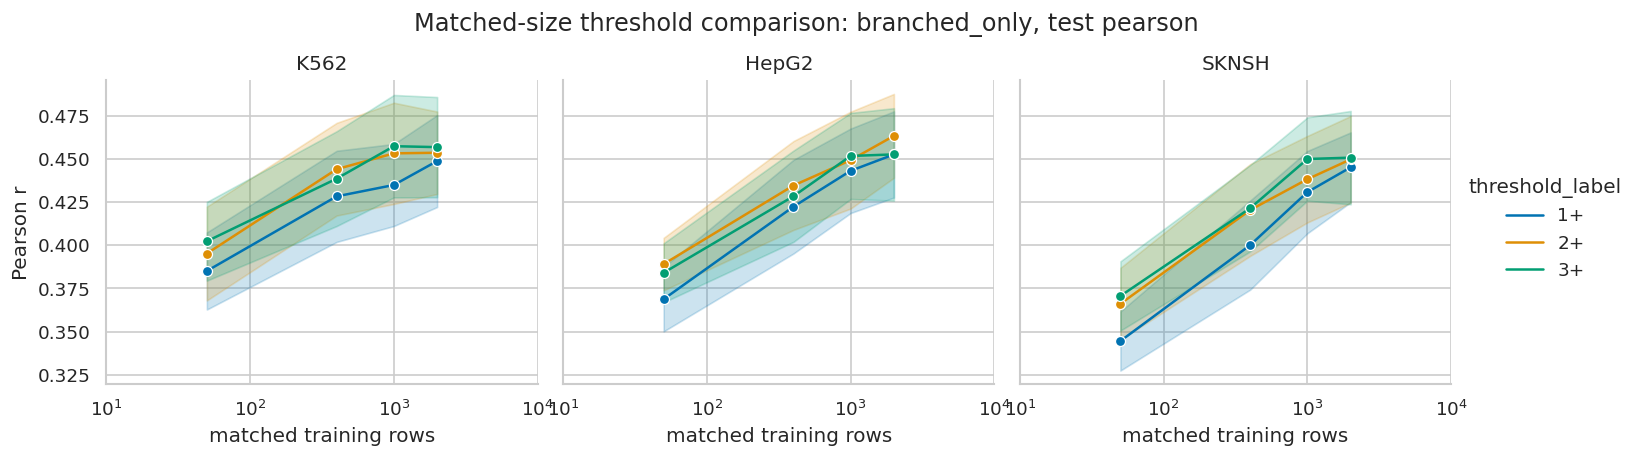

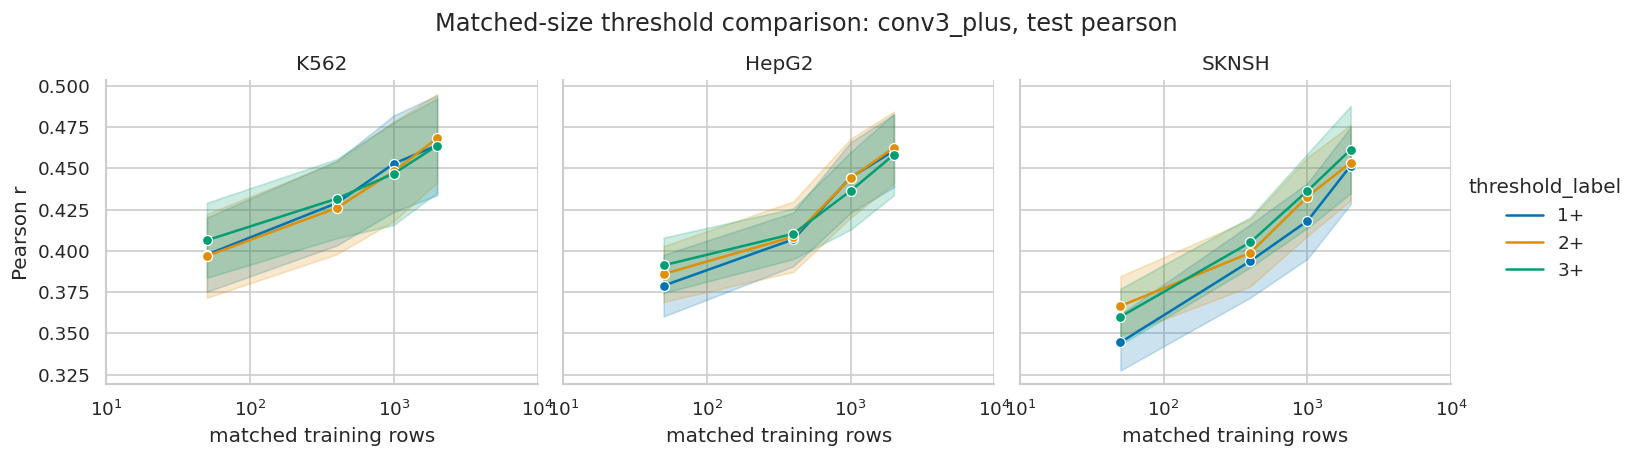

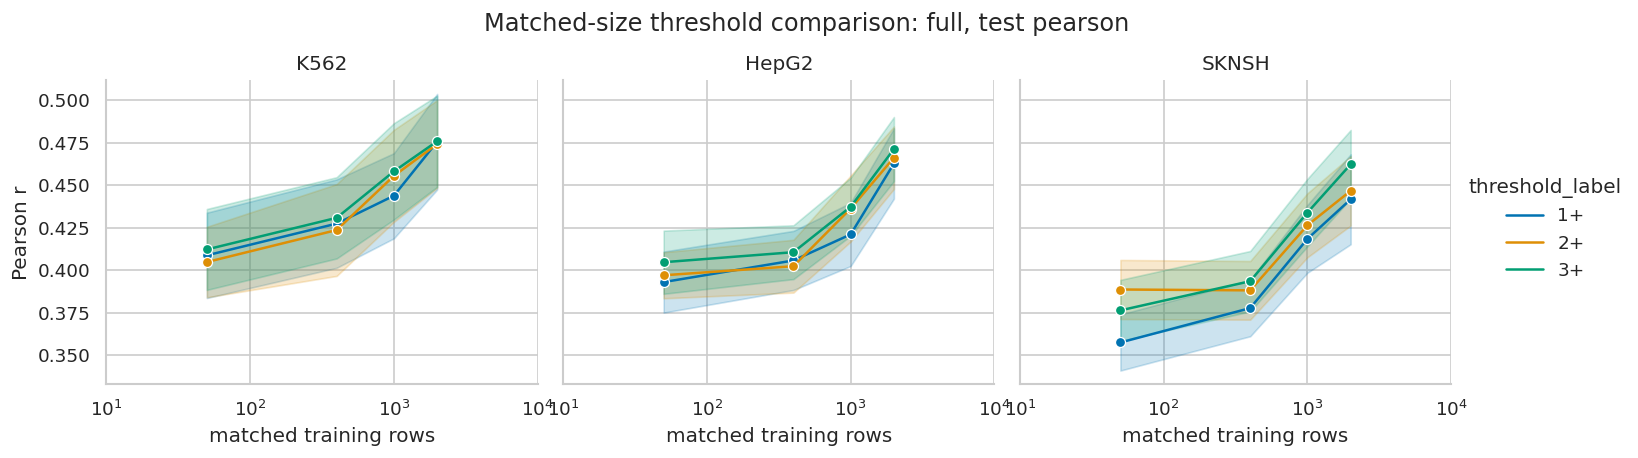

In [15]:
MATCHED_SIZES = [50, 400, 1000, 2000]
matched = run_long[
    (run_long["metric_root"] == PRIMARY_METRIC_ROOT)
    & (run_long["split"] == PRIMARY_SPLIT)
    & (run_long["train_size"].isin(MATCHED_SIZES))
].copy()

for scope in UNFREEZE_SCOPE_ORDER:
    sub = matched[matched["unfreeze_scope"] == scope]
    if sub.empty:
        continue
    g = sns.relplot(
        data=sub,
        x="train_size",
        y="value",
        hue="threshold_label",
        col="init_head",
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.6,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": True},
    )
    for ax in g.axes.flat:
        apply_log10_xaxis(ax, sub["train_size"])
    g.set_axis_labels("matched training rows", METRIC_SPECS[PRIMARY_METRIC_ROOT]["label"])
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Matched-size threshold comparison: {scope}, {PRIMARY_SPLIT} {PRIMARY_METRIC_ROOT}", y=1.05)
    plt.show()

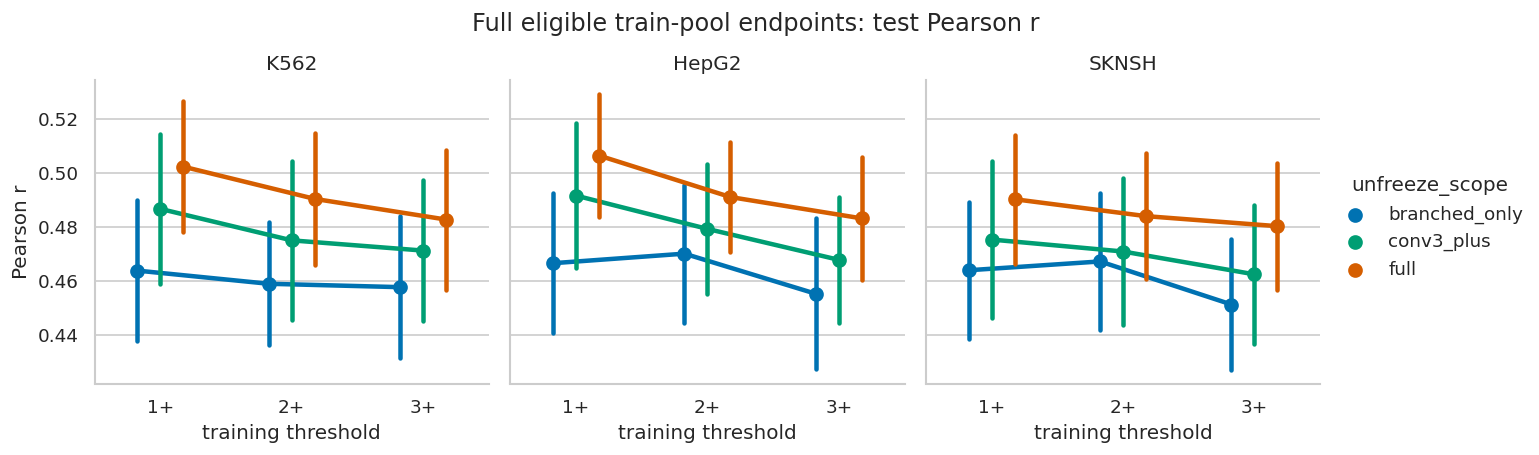

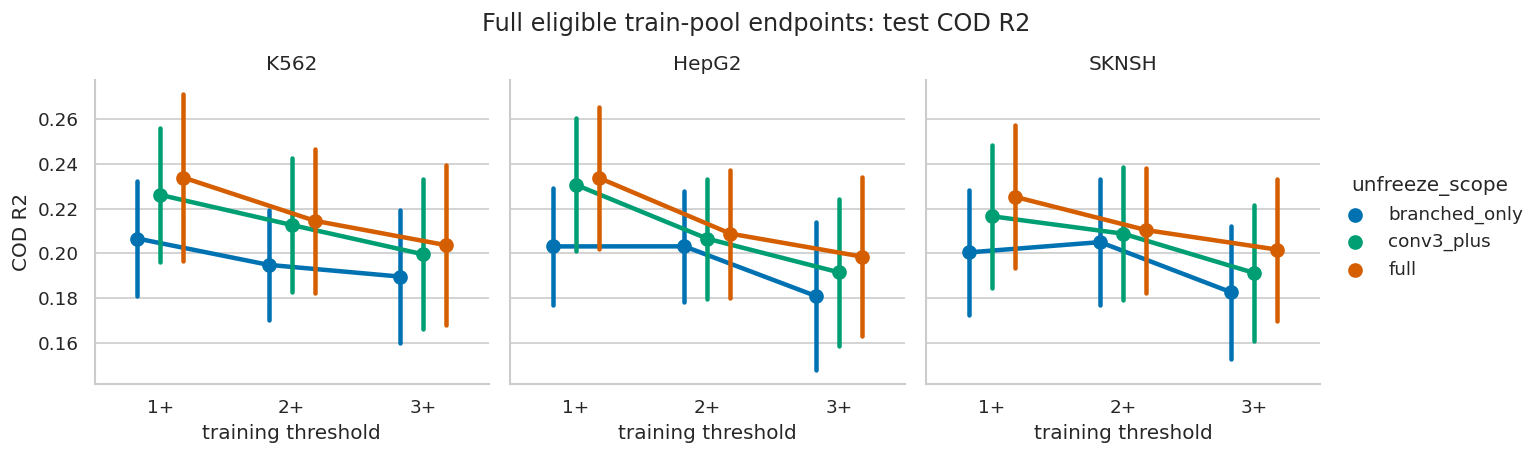

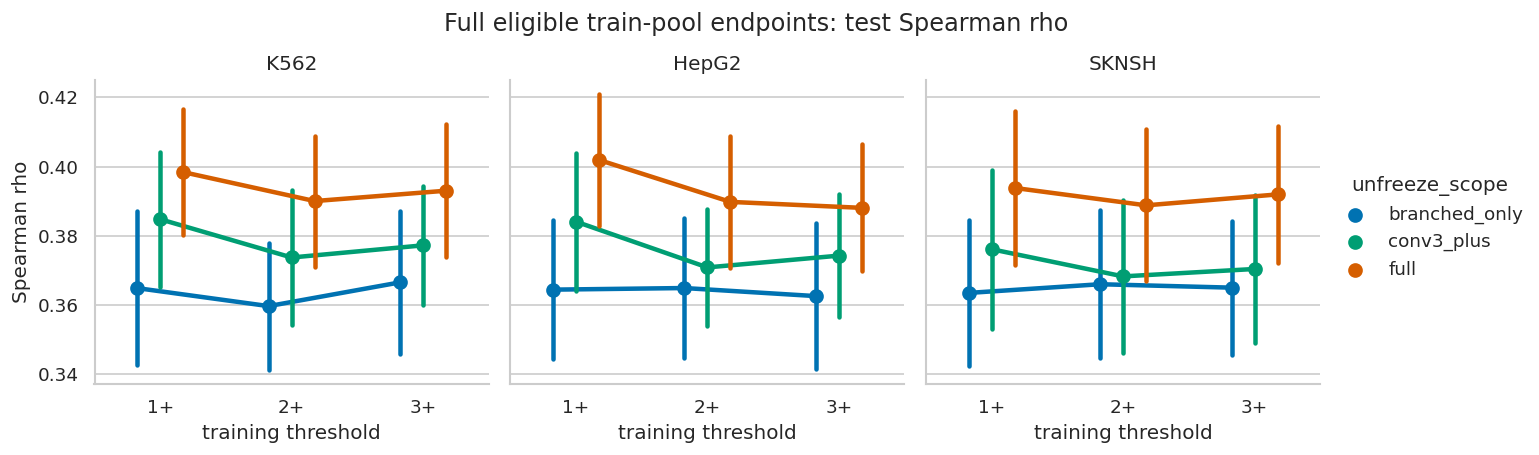

In [16]:
full_runs = runs[runs["train_size"] == runs["train_pool_eligible_size"]].copy()
full_long = make_metric_long(full_runs)

for metric_root in ["pearson", "cod_r2", "spearman"]:
    plot_df = full_long[(full_long["metric_root"] == metric_root) & (full_long["split"] == "test")].copy()
    g = sns.catplot(
        data=plot_df,
        x="threshold_label",
        y="value",
        hue="unfreeze_scope",
        col="init_head",
        kind="point",
        dodge=0.35,
        errorbar="se",
        height=3.6,
        aspect=1.05,
        palette=SCOPE_PALETTE,
    )
    g.set_axis_labels("training threshold", METRIC_SPECS[metric_root]["label"])
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Full eligible train-pool endpoints: test {METRIC_SPECS[metric_root]['label']}", y=1.05)
    plt.show()


## Validation-Selected HPO Summary

Mean-validation-selected configs by init head. This is the main HPO selection view.

,init_head,train_threshold,train_size,is_full_pool,unfreeze_scope,val_pearson_mean,val_pearson_se,test_pearson_mean,test_pearson_se,test_r2_cod_mean,best_epoch_mean
79,HepG2,1,4295,True,full,0.514367,0.009504,0.506604,0.022853,0.233702,3.000
34,K562,1,4295,True,full,0.511005,0.012496,0.502483,0.024398,0.233864,2.875
124,SKNSH,1,4295,True,full,0.505763,0.015806,0.490399,0.023979,0.225314,2.750


Overall mean-validation-selected config.

,init_head,train_threshold,train_size,is_full_pool,unfreeze_scope,val_pearson_mean,val_pearson_se,test_pearson_mean,test_pearson_se,test_r2_cod_mean,best_epoch_mean
79,HepG2,1,4295,True,full,0.514367,0.009504,0.506604,0.022853,0.233702,3.0


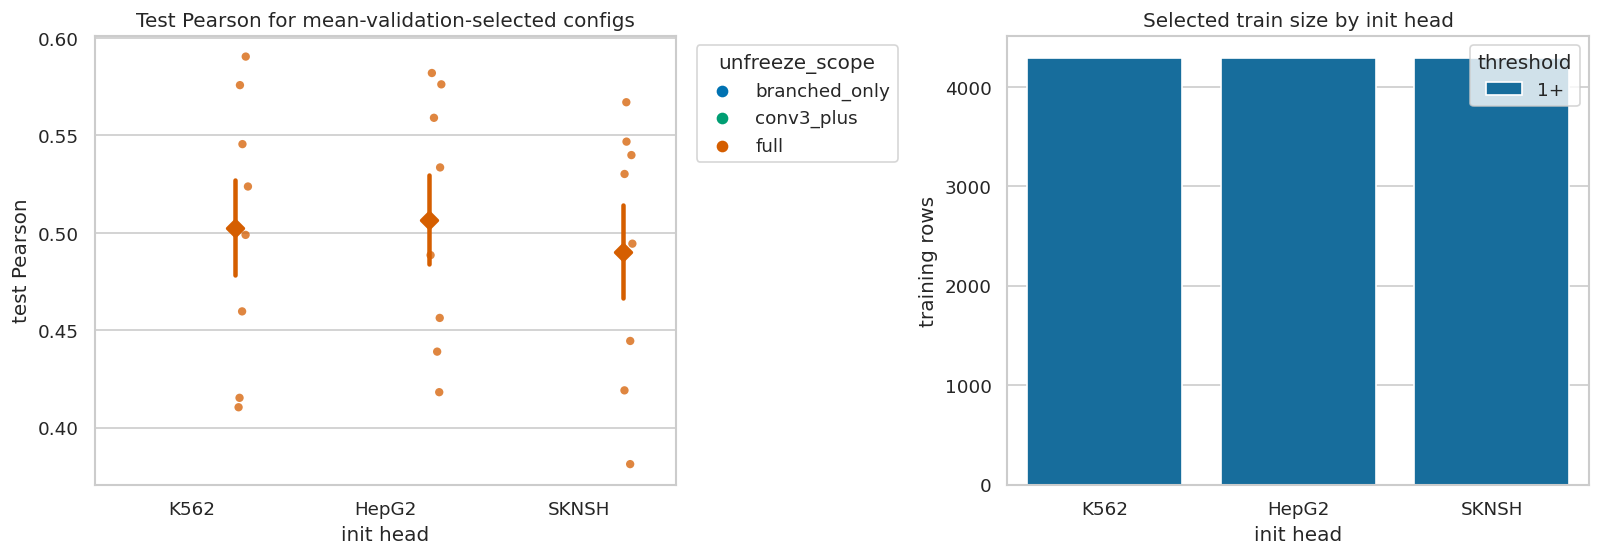

Diagnostic: per-seed/per-head validation picks. This is useful for seeing validation noise, not for choosing the final HPO config.

,init_head,train_threshold,train_size,unfreeze_scope,n_selected,val_pearson_mean,test_pearson_mean,test_pearson_se,test_r2_cod_mean,best_epoch_mean
11,SKNSH,1,50,branched_only,5,0.362406,0.344555,0.013512,0.067992,18.200000
5,HepG2,1,50,branched_only,3,0.368016,0.363505,0.028678,0.087705,18.333333
2,K562,2,50,full,3,0.368101,0.351728,0.029606,0.070350,58.666667
3,K562,3,50,branched_only,2,0.356689,0.364250,0.014529,0.069980,14.000000
4,K562,3,50,full,1,0.455459,0.486610,NaN,0.184191,48.000000
1,K562,1,50,full,1,0.390382,0.459523,NaN,0.172802,11.000000
8,HepG2,2,50,branched_only,1,0.367113,0.430885,NaN,0.166782,21.000000
0,K562,1,50,branched_only,1,0.338294,0.424367,NaN,0.178858,26.000000
10,HepG2,3,50,branched_only,1,0.435658,0.398442,NaN,0.147459,20.000000
13,SKNSH,1,50,full,1,0.352905,0.397562,NaN,0.108079,16.000000


In [17]:
def config_key_columns(frame: pd.DataFrame) -> list[str]:
    keys = ["setting", "init_head", "unfreeze_scope", "train_threshold", "train_size", "head_lr", "backbone_lr"]
    return [col for col in keys if col in frame.columns]


def rows_for_selected_configs(frame: pd.DataFrame, selected_configs: pd.DataFrame) -> pd.DataFrame:
    keys = config_key_columns(frame)
    return frame.merge(selected_configs[keys].drop_duplicates(), on=keys, how="inner")


def select_best_by_validation(frame: pd.DataFrame, *, metric_root="pearson", group_cols=("seed", "init_head")) -> pd.DataFrame:
    val_col = METRIC_SPECS[metric_root]["cols"]["val"]
    ascending = not METRIC_SPECS[metric_root]["higher_is_better"]
    sorted_frame = frame.sort_values(list(group_cols) + [val_col], ascending=[True] * len(group_cols) + [ascending])
    return sorted_frame.groupby(list(group_cols), observed=True, as_index=False).tail(1).copy()


# Recommended HPO view: rank configs by mean validation performance across all 8 seeds.
mean_val_selected_configs = (
    perf_summary.sort_values("val_pearson_mean", ascending=False)
    .groupby("init_head", observed=True, as_index=False)
    .head(1)
    .copy()
)
overall_mean_val_selected_config = perf_summary.sort_values("val_pearson_mean", ascending=False).head(1).copy()
validation_selected_runs = rows_for_selected_configs(runs, mean_val_selected_configs)
overall_validation_selected_runs = rows_for_selected_configs(runs, overall_mean_val_selected_config)

display(Markdown("Mean-validation-selected configs by init head. This is the main HPO selection view."))
display(mean_val_selected_configs[["init_head", "train_threshold", "train_size", "is_full_pool", "unfreeze_scope", "val_pearson_mean", "val_pearson_se", "test_pearson_mean", "test_pearson_se", "test_r2_cod_mean", "best_epoch_mean"]])

display(Markdown("Overall mean-validation-selected config."))
display(overall_mean_val_selected_config[["init_head", "train_threshold", "train_size", "is_full_pool", "unfreeze_scope", "val_pearson_mean", "val_pearson_se", "test_pearson_mean", "test_pearson_se", "test_r2_cod_mean", "best_epoch_mean"]])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
sns.stripplot(
    data=validation_selected_runs,
    x="init_head",
    y="test_pearson",
    hue="unfreeze_scope",
    dodge=True,
    alpha=0.75,
    palette=SCOPE_PALETTE,
    ax=axes[0],
)
sns.pointplot(
    data=validation_selected_runs,
    x="init_head",
    y="test_pearson",
    hue="unfreeze_scope",
    dodge=0.45,
    errorbar="se",
    palette=SCOPE_PALETTE,
    markers="D",
    linestyles="",
    ax=axes[0],
)
axes[0].set_title("Test Pearson for mean-validation-selected configs")
axes[0].set_xlabel("init head")
axes[0].set_ylabel("test Pearson")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[: len(UNFREEZE_SCOPE_ORDER)], labels[: len(UNFREEZE_SCOPE_ORDER)], title="unfreeze_scope", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=mean_val_selected_configs,
    x="init_head",
    y="train_size",
    hue="threshold_label",
    ax=axes[1],
)
axes[1].set_title("Selected train size by init head")
axes[1].set_xlabel("init head")
axes[1].set_ylabel("training rows")
axes[1].legend(title="threshold")
plt.tight_layout()
plt.show()

# Diagnostic only: if each seed/head independently picks the best validation row, tiny-N configs can win by variance.
per_seed_head_selected = select_best_by_validation(runs, metric_root=PRIMARY_METRIC_ROOT, group_cols=("seed", "init_head"))
per_seed_selection_summary = (
    per_seed_head_selected.groupby(["init_head", "train_threshold", "train_size", "unfreeze_scope"], observed=True)
    .agg(
        n_selected=("seed", "nunique"),
        val_pearson_mean=("val_pearson", "mean"),
        test_pearson_mean=("test_pearson", "mean"),
        test_pearson_se=("test_pearson", standard_error),
        test_r2_cod_mean=("test_r2_cod", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .reset_index()
    .sort_values(["n_selected", "test_pearson_mean"], ascending=[False, False])
)

display(Markdown("Diagnostic: per-seed/per-head validation picks. This is useful for seeing validation noise, not for choosing the final HPO config."))
display(per_seed_selection_summary.head(30))


## Validation/Test Agreement and Generalization Gaps

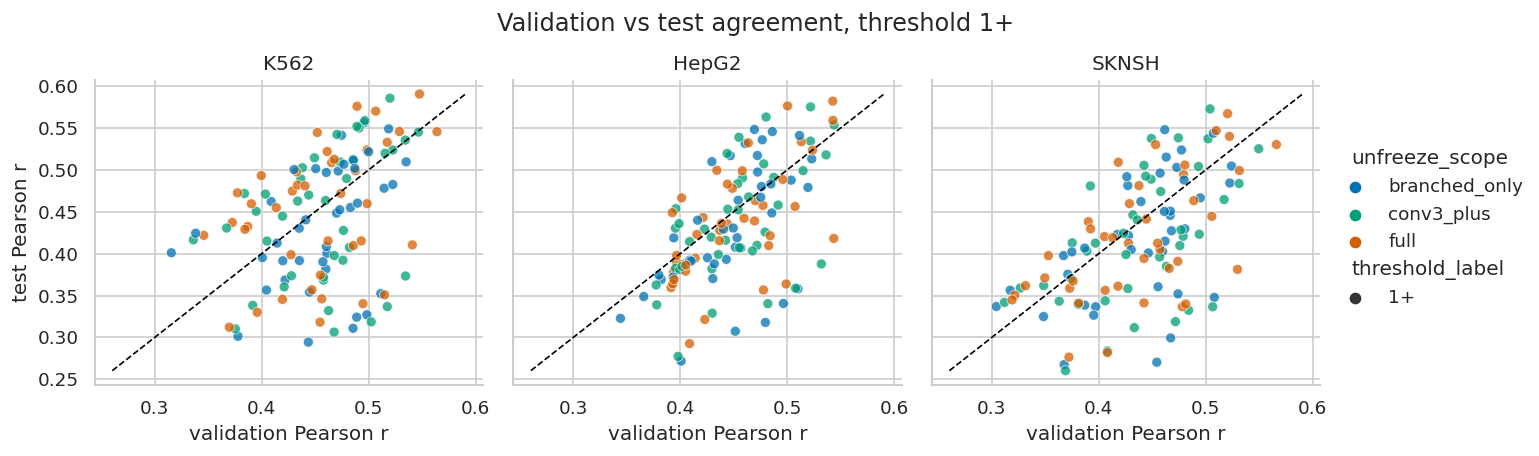

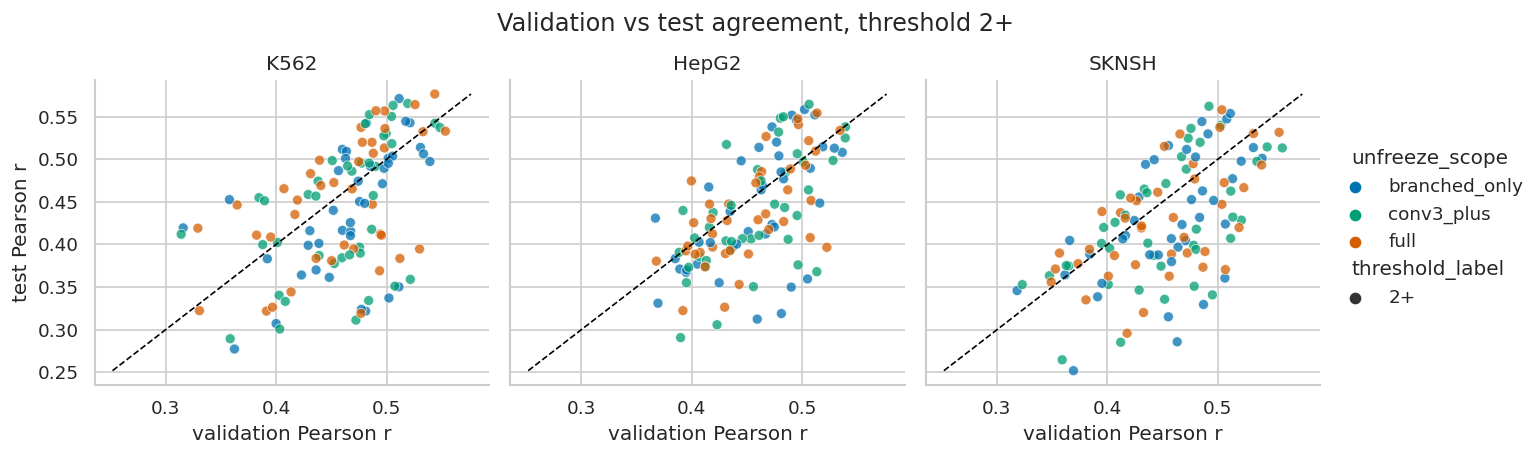

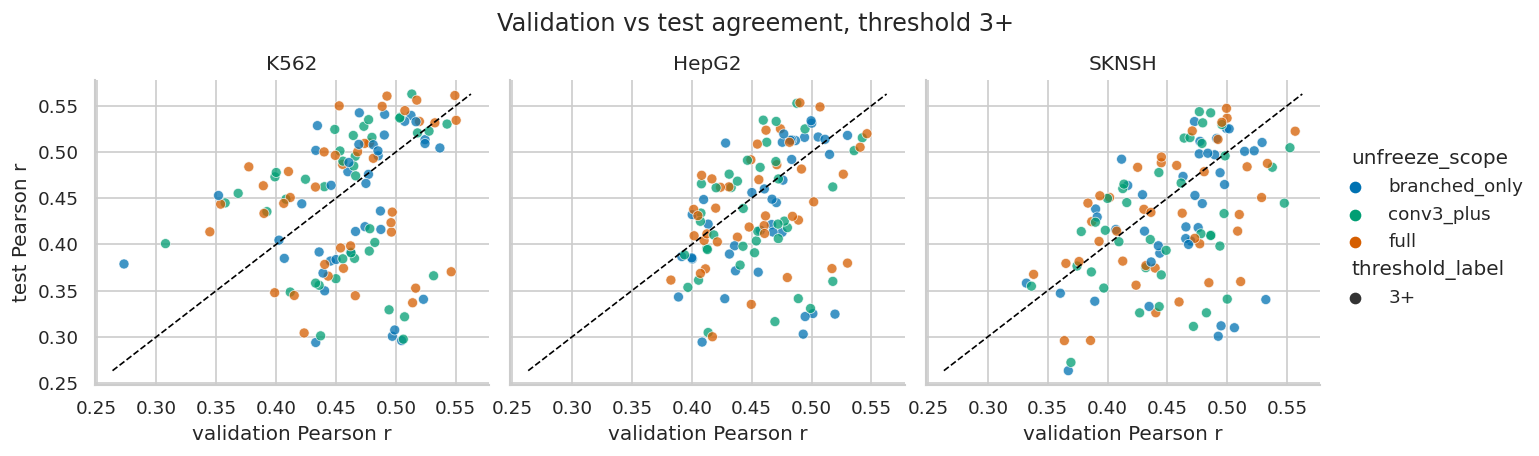

In [18]:
metric_root = PRIMARY_METRIC_ROOT
val_col = METRIC_SPECS[metric_root]["cols"]["val"]
test_col = METRIC_SPECS[metric_root]["cols"]["test"]
scatter_df = runs.copy()

for threshold in THRESHOLD_ORDER:
    sub = scatter_df[scatter_df["train_threshold"] == threshold]
    if sub.empty:
        continue
    g = sns.relplot(
        data=sub,
        x=val_col,
        y=test_col,
        hue="unfreeze_scope",
        col="init_head",
        style="threshold_label",
        kind="scatter",
        alpha=0.75,
        height=3.6,
        aspect=1.05,
        palette=SCOPE_PALETTE,
    )
    for ax in g.axes.flat:
        finite = np.isfinite(sub[val_col]) & np.isfinite(sub[test_col])
        if finite.any():
            lo = min(sub.loc[finite, val_col].min(), sub.loc[finite, test_col].min())
            hi = max(sub.loc[finite, val_col].max(), sub.loc[finite, test_col].max())
            ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1)
    g.set_axis_labels(f"validation {METRIC_SPECS[metric_root]['label']}", f"test {METRIC_SPECS[metric_root]['label']}")
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Validation vs test agreement, threshold {threshold}+", y=1.05)
    plt.show()


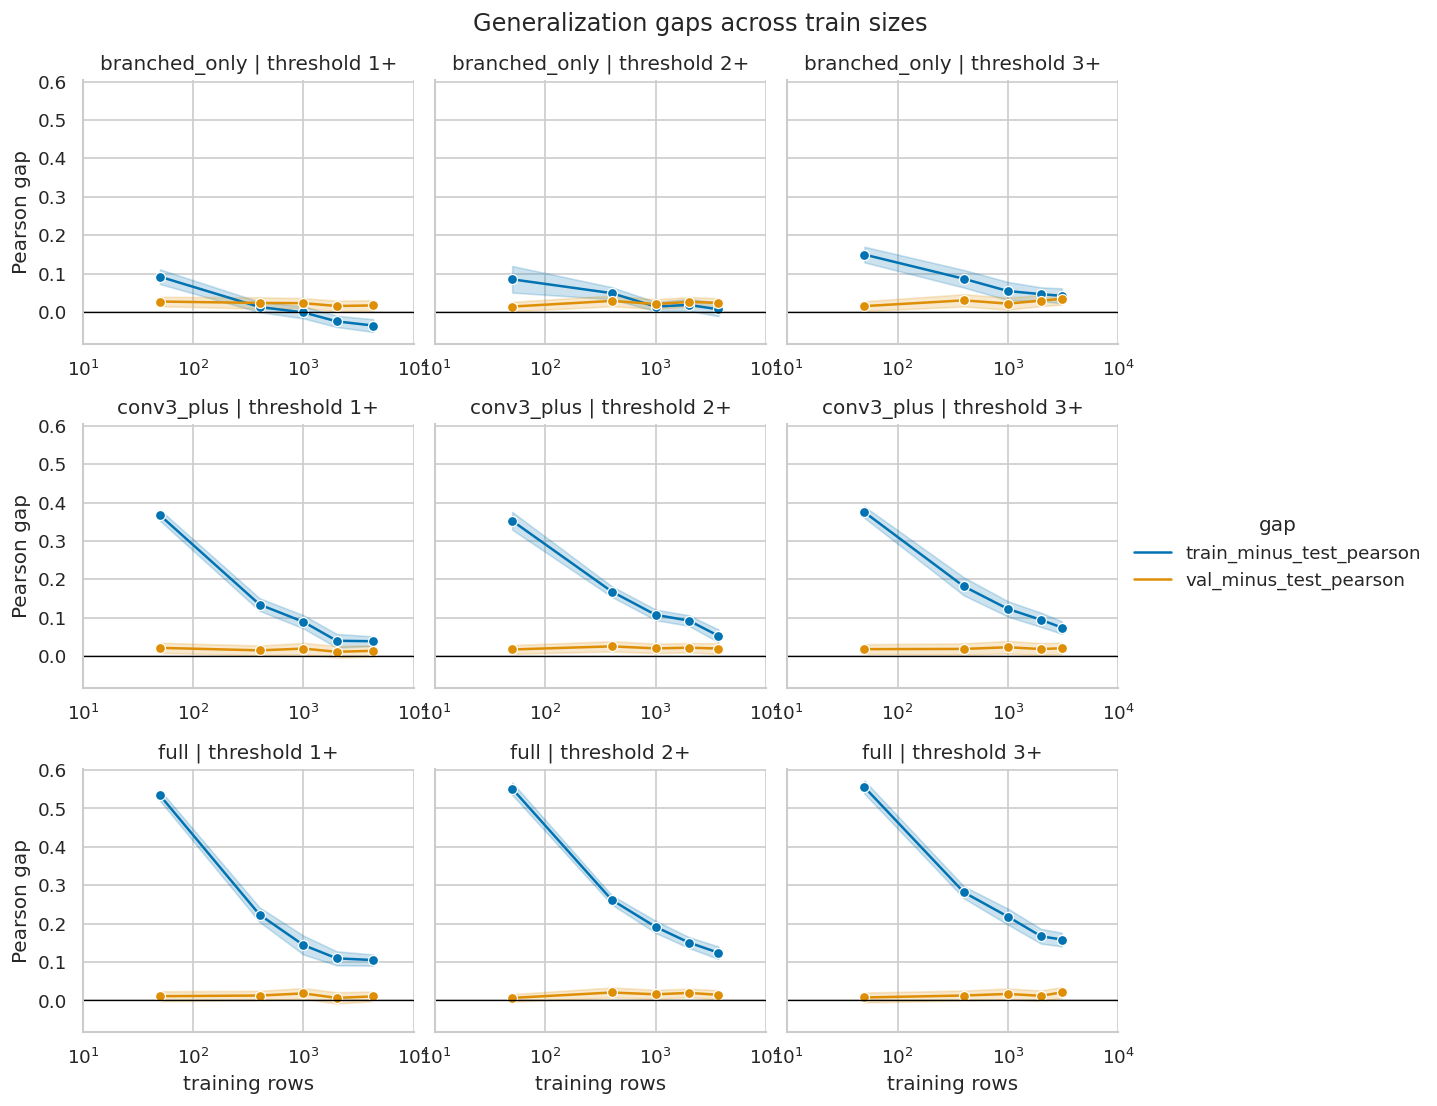

In [19]:
gap_df = runs.copy()
gap_df["train_minus_test_pearson"] = gap_df["train_pearson"] - gap_df["test_pearson"]
gap_df["val_minus_test_pearson"] = gap_df["val_pearson"] - gap_df["test_pearson"]
gap_long = gap_df.melt(
    id_vars=["seed", "init_head", "unfreeze_scope", "train_threshold", "threshold_label", "train_size"],
    value_vars=["train_minus_test_pearson", "val_minus_test_pearson"],
    var_name="gap",
    value_name="delta_pearson",
)

g = sns.relplot(
    data=gap_long,
    x="train_size",
    y="delta_pearson",
    hue="gap",
    row="unfreeze_scope",
    col="threshold_label",
    kind="line",
    marker="o",
    estimator="mean",
    errorbar="se",
    height=3.0,
    aspect=1.08,
    facet_kws={"sharex": False, "sharey": True},
)
for ax in g.axes.flat:
    apply_log10_xaxis(ax, gap_long["train_size"])
    ax.axhline(0, color="black", linewidth=0.8)
g.set_axis_labels("training rows", "Pearson gap")
g.set_titles("{row_name} | threshold {col_name}")
g.fig.suptitle("Generalization gaps across train sizes", y=1.02)
plt.show()


## Zero-Shot Baseline

,init_head,train_threshold,train_size,unfreeze_scope,val_pearson_mean,test_pearson_mean,zero_test_pearson_mean,delta_test_pearson_vs_zero,test_r2_cod_mean,zero_test_r2_cod_mean
0,HepG2,1,4295,full,0.514367,0.506604,0.378754,0.127850,0.233702,-19.945510
1,K562,1,4295,full,0.511005,0.502483,0.391926,0.110557,0.233864,-21.578297
2,SKNSH,1,4295,full,0.505763,0.490399,0.355873,0.134526,0.225314,-21.524475


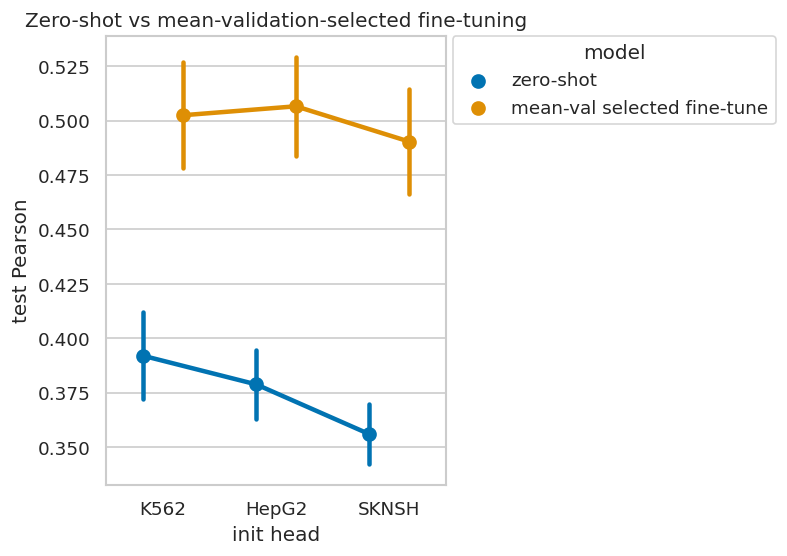

In [20]:
zero_summary = (
    zero_shot.groupby("init_head", observed=True)
    .agg(
        zero_test_pearson_mean=("pearson", "mean"),
        zero_test_pearson_se=("pearson", standard_error),
        zero_test_r2_cod_mean=("r2_cod", "mean"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

comparison = mean_val_selected_configs.merge(zero_summary, on="init_head", how="left")
comparison["delta_test_pearson_vs_zero"] = comparison["test_pearson_mean"] - comparison["zero_test_pearson_mean"]
display(comparison[["init_head", "train_threshold", "train_size", "unfreeze_scope", "val_pearson_mean", "test_pearson_mean", "zero_test_pearson_mean", "delta_test_pearson_vs_zero", "test_r2_cod_mean", "zero_test_r2_cod_mean"]])

plot_parts = []
z = zero_shot.copy()
z["model"] = "zero-shot"
z["test_pearson_plot"] = z["pearson"]
plot_parts.append(z[["seed", "init_head", "model", "test_pearson_plot"]])
ft = validation_selected_runs.copy()
ft["model"] = "mean-val selected fine-tune"
ft["test_pearson_plot"] = ft["test_pearson"]
plot_parts.append(ft[["seed", "init_head", "model", "test_pearson_plot"]])
zero_compare_plot = pd.concat(plot_parts, ignore_index=True)

plt.figure(figsize=(8.5, 4.8))
ax = sns.pointplot(
    data=zero_compare_plot,
    x="init_head",
    y="test_pearson_plot",
    hue="model",
    errorbar="se",
    dodge=0.35,
)
ax.set_xlabel("init head")
ax.set_ylabel("test Pearson")
ax.set_title("Zero-shot vs mean-validation-selected fine-tuning")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()


## Per-Epoch Training Dynamics

Best mean-validation config:
  init_head: HepG2
  unfreeze_scope: full
  train_threshold: 1
  train_size: 4295
  val_pearson_mean: 0.5143670147545145
  test_pearson_mean: 0.5066035511019708
  best_epoch_mean: 3.0


Selected epoch-dynamics configs:

,init_head,unfreeze_scope,train_threshold,train_size,is_full_pool,val_pearson_mean,val_pearson_se,test_pearson_mean,test_pearson_se,best_epoch_mean
0,HepG2,full,1,4295,True,0.514367,0.009504,0.506604,0.022853,3.0


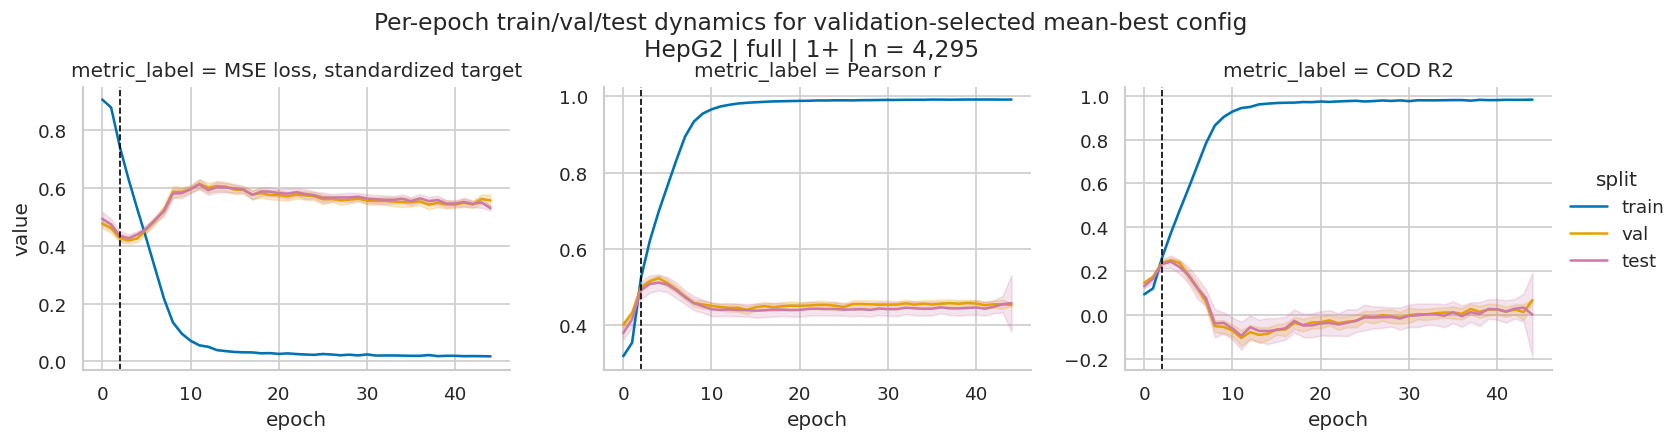

Selected epoch-dynamics configs:

,init_head,unfreeze_scope,train_threshold,train_size,is_full_pool,val_pearson_mean,val_pearson_se,test_pearson_mean,test_pearson_se,best_epoch_mean
0,HepG2,full,1,4295,True,0.514367,0.009504,0.506604,0.022853,3.000
1,HepG2,conv3_plus,1,4295,True,0.504212,0.010159,0.491741,0.026944,3.875
2,HepG2,branched_only,1,4295,True,0.480639,0.011461,0.466654,0.026081,17.125


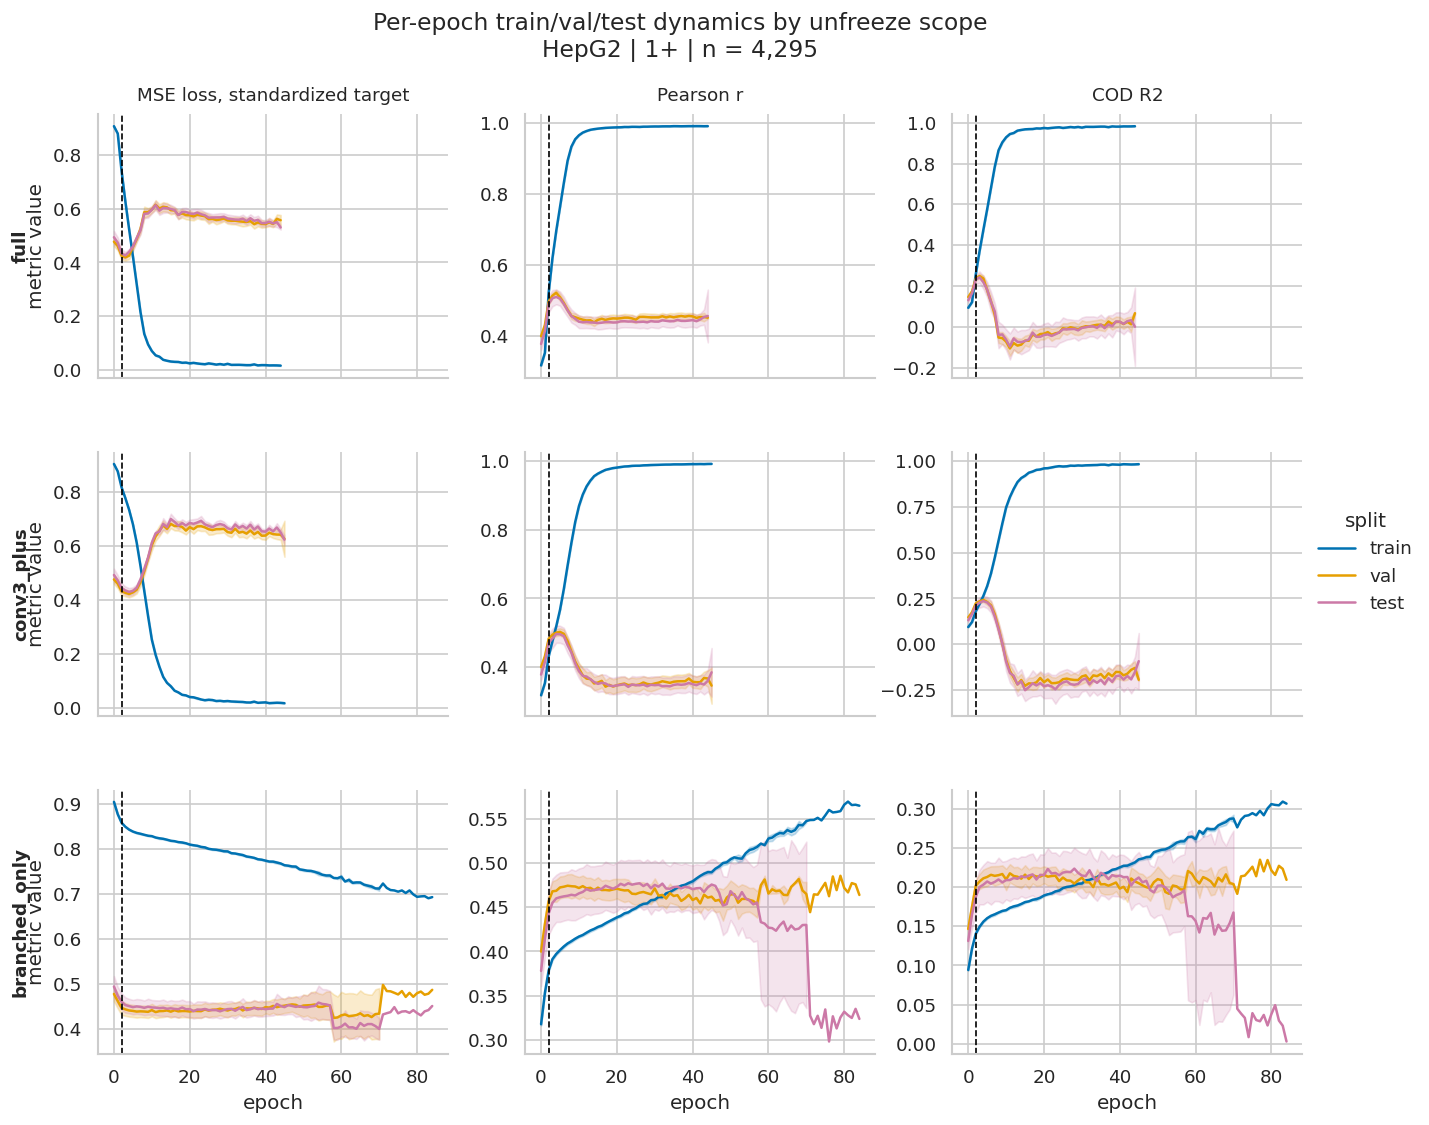

In [21]:
def _as_list(values):
    if values is None:
        return None
    if isinstance(values, (str, bytes)):
        return [values]
    if np.isscalar(values):
        return [values]
    return list(values)


def _filter_values(frame: pd.DataFrame, column: str, values) -> pd.DataFrame:
    values = _as_list(values)
    if values is None:
        return frame
    return frame[frame[column].isin(values)].copy()


def _format_threshold(value) -> str:
    if pd.isna(value):
        return "NA"
    try:
        return f"{int(value)}+"
    except (TypeError, ValueError):
        return str(value)


def _format_train_size(value) -> str:
    if pd.isna(value):
        return "n = NA"
    try:
        return f"n = {int(value):,}"
    except (TypeError, ValueError):
        return f"n = {value}"


def _format_epoch_config_piece(row: pd.Series, column: str) -> str:
    if column == "train_threshold":
        return _format_threshold(row[column])
    if column == "train_size":
        return _format_train_size(row[column])
    return str(row[column])


def make_epoch_config_label(row: pd.Series) -> str:
    return " | ".join(
        _format_epoch_config_piece(row, column)
        for column in ["init_head", "unfreeze_scope", "train_threshold", "train_size"]
    )


def add_epoch_dynamics_labels(selected: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """Add compact labels for epoch dynamics facets.

    Shared config fields go into the figure title; only varying fields become row labels.
    This keeps multi-row facet titles readable.
    """
    selected = selected.copy()
    label_cols = ["init_head", "unfreeze_scope", "train_threshold", "train_size"]
    common_cols = [col for col in label_cols if selected[col].nunique(dropna=False) == 1]
    varying_cols = [col for col in label_cols if col not in common_cols]

    selected["config_label"] = selected.apply(make_epoch_config_label, axis=1)
    if varying_cols:
        selected["row_label"] = selected.apply(
            lambda row: " | ".join(_format_epoch_config_piece(row, col) for col in varying_cols),
            axis=1,
        )
    else:
        selected["row_label"] = selected["config_label"]

    shared_label = " | ".join(
        _format_epoch_config_piece(selected.iloc[0], col) for col in common_cols
    )
    return selected, shared_label


def select_epoch_dynamics_configs(
    config_summary: pd.DataFrame = perf_summary,
    *,
    init_heads=None,
    unfreeze_scopes=None,
    train_thresholds=None,
    train_sizes=None,
    selection_metric: str = "val_pearson_mean",
    select_best_train_size_by_val: bool = True,
    max_configs: int | None = 12,
) -> pd.DataFrame:
    """Select configs for epoch-dynamics plots.

    If train_sizes is omitted and select_best_train_size_by_val is True, the function picks
    the best validation-Pearson train size within each requested head/scope/threshold group.
    Provide train_sizes=[...] when you want a fixed matched-size comparison instead.
    """
    summary = config_summary.copy()
    summary = _filter_values(summary, "init_head", init_heads)
    summary = _filter_values(summary, "unfreeze_scope", unfreeze_scopes)
    summary = _filter_values(summary, "train_threshold", train_thresholds)
    summary = _filter_values(summary, "train_size", train_sizes)
    if summary.empty:
        raise ValueError("No configs matched the requested filters.")

    if selection_metric not in summary.columns:
        raise ValueError(f"selection_metric={selection_metric!r} is not in config_summary.")

    summary = summary.sort_values(selection_metric, ascending=False).copy()

    if train_sizes is None and select_best_train_size_by_val:
        group_cols = []
        if init_heads is not None:
            group_cols.append("init_head")
        if unfreeze_scopes is not None:
            group_cols.append("unfreeze_scope")
        if train_thresholds is not None:
            group_cols.append("train_threshold")

        if group_cols:
            best_idx = summary.groupby(group_cols, observed=True)[selection_metric].idxmax()
            summary = summary.loc[best_idx].sort_values(selection_metric, ascending=False)
        else:
            summary = summary.head(1)

    if max_configs is not None and len(summary) > max_configs:
        display(Markdown(f"Keeping the top {max_configs} of {len(summary)} matched configs by `{selection_metric}`."))
        summary = summary.head(max_configs)

    return summary.reset_index(drop=True)


def plot_epoch_dynamics(
    history_frame: pd.DataFrame = history_long,
    config_summary: pd.DataFrame = perf_summary,
    *,
    init_heads=None,
    unfreeze_scopes=None,
    train_thresholds=None,
    train_sizes=None,
    metric_roots=("loss", "pearson", "cod_r2"),
    splits=("train", "val", "test"),
    selection_metric: str = "val_pearson_mean",
    select_best_train_size_by_val: bool = True,
    max_configs: int | None = 12,
    frozen_epochs: int | None = None,
    title: str | None = None,
    subplot_title_size: int = 11,
    figure_title_size: int = 14,
    row_label_size: int = 11,
    show_shared_config_in_title: bool = True,
):
    """Plot per-epoch train/val/test dynamics for selected HPO configs.

    Pass lists such as init_heads=["HepG2"], unfreeze_scopes=["branched_only", "conv3_plus", "full"],
    train_thresholds=[1, 2, 3], and optionally train_sizes=[2000] for matched-size views.
    """
    selected = select_epoch_dynamics_configs(
        config_summary,
        init_heads=init_heads,
        unfreeze_scopes=unfreeze_scopes,
        train_thresholds=train_thresholds,
        train_sizes=train_sizes,
        selection_metric=selection_metric,
        select_best_train_size_by_val=select_best_train_size_by_val,
        max_configs=max_configs,
    )
    selected, shared_config_label = add_epoch_dynamics_labels(selected)

    display_cols = [
        "init_head",
        "unfreeze_scope",
        "train_threshold",
        "train_size",
        "is_full_pool",
        "val_pearson_mean",
        "val_pearson_se",
        "test_pearson_mean",
        "test_pearson_se",
        "best_epoch_mean",
    ]
    display_cols = [col for col in display_cols if col in selected.columns]
    display(Markdown("Selected epoch-dynamics configs:"))
    display(selected[display_cols])

    join_cols = ["init_head", "unfreeze_scope", "train_threshold", "train_size"]
    selected_keys = selected[join_cols + ["config_label", "row_label"]].drop_duplicates().copy()

    hist = history_frame.copy()
    for frame in (hist, selected_keys):
        frame["init_head"] = frame["init_head"].astype(str)
        frame["unfreeze_scope"] = frame["unfreeze_scope"].astype(str)
        frame["train_threshold"] = pd.to_numeric(frame["train_threshold"], errors="coerce").astype("Int64")
        frame["train_size"] = pd.to_numeric(frame["train_size"], errors="coerce").astype("Int64")

    hist_focus = hist.merge(selected_keys, on=join_cols, how="inner")
    metric_roots = tuple(metric_roots)
    splits = tuple(splits)
    hist_focus = hist_focus[
        hist_focus["metric_root"].isin(metric_roots)
        & hist_focus["split"].isin(splits)
    ].copy()
    if hist_focus.empty:
        raise ValueError("No epoch-history rows matched the selected configs/metrics/splits.")

    metric_labels = [HISTORY_METRIC_SPECS[k]["label"] for k in metric_roots if k in HISTORY_METRIC_SPECS]
    hist_focus["metric_label"] = pd.Categorical(hist_focus["metric_label"], categories=metric_labels, ordered=True)
    hist_focus["split"] = pd.Categorical(hist_focus["split"], categories=[s for s in SPLIT_ORDER if s in splits], ordered=True)
    hist_focus["row_label"] = pd.Categorical(hist_focus["row_label"], categories=selected["row_label"].tolist(), ordered=True)

    relplot_kwargs = dict(
        data=hist_focus,
        x="epoch",
        y="value",
        hue="split",
        col="metric_label",
        kind="line",
        estimator="mean",
        errorbar="se",
        height=3.15 if len(selected) > 1 else 3.7,
        aspect=1.22,
        palette=SPLIT_PALETTE,
        facet_kws={"sharey": False, "sharex": True},
    )
    if len(selected) > 1:
        relplot_kwargs["row"] = "row_label"

    g = sns.relplot(**relplot_kwargs)
    frozen_epochs = example_manifest.get("frozen_epochs", 2) if frozen_epochs is None else frozen_epochs
    for ax in g.axes.flat:
        ax.axvline(frozen_epochs, color="black", linestyle="--", linewidth=1.0)

    col_names = list(g.col_names) if g.col_names is not None else metric_labels
    row_names = list(g.row_names) if g.row_names is not None else [None]
    for row_idx, row_name in enumerate(row_names):
        for col_idx, col_name in enumerate(col_names):
            ax = g.axes[row_idx, col_idx]
            ax.set_title(str(col_name) if row_idx == 0 else "", fontsize=subplot_title_size, pad=8)
            if col_idx == 0:
                ax.set_ylabel("metric value")
            else:
                ax.set_ylabel("")
        if row_name is not None:
            g.axes[row_idx, 0].annotate(
                str(row_name),
                xy=(-0.22, 0.5),
                xycoords="axes fraction",
                ha="center",
                va="center",
                rotation=90,
                fontsize=row_label_size,
                fontweight="bold",
            )

    g.set_xlabels("epoch")
    base_title = title or "Per-epoch train/val/test dynamics"
    if show_shared_config_in_title and shared_config_label:
        base_title = f"{base_title}\n{shared_config_label}"
    top = 0.90 if len(selected) > 1 else 0.82
    if not (show_shared_config_in_title and shared_config_label):
        top += 0.04
    g.fig.subplots_adjust(top=top, left=0.11 if len(selected) > 1 else 0.08, hspace=0.28, wspace=0.22)
    g.fig.suptitle(base_title, y=0.99, fontsize=figure_title_size)
    plt.show()
    return g, selected, hist_focus


# Default view: reproduce the previous single mean-validation-best config plot.
best_cfg = top_by_val.iloc[0].to_dict()
print("Best mean-validation config:")
for key in ["init_head", "unfreeze_scope", "train_threshold", "train_size", "val_pearson_mean", "test_pearson_mean", "best_epoch_mean"]:
    print(f"  {key}: {best_cfg.get(key)}")

_ = plot_epoch_dynamics(
    init_heads=[best_cfg["init_head"]],
    unfreeze_scopes=[best_cfg["unfreeze_scope"]],
    train_thresholds=[best_cfg["train_threshold"]],
    train_sizes=[best_cfg["train_size"]],
    title="Per-epoch train/val/test dynamics for validation-selected mean-best config",
)

# Compare unfreeze scopes for the same validation-selected head/threshold/train size.
_ = plot_epoch_dynamics(
    init_heads=[best_cfg["init_head"]],
    unfreeze_scopes=UNFREEZE_SCOPE_ORDER,
    train_thresholds=[best_cfg["train_threshold"]],
    train_sizes=[best_cfg["train_size"]],
    title="Per-epoch train/val/test dynamics by unfreeze scope",
)


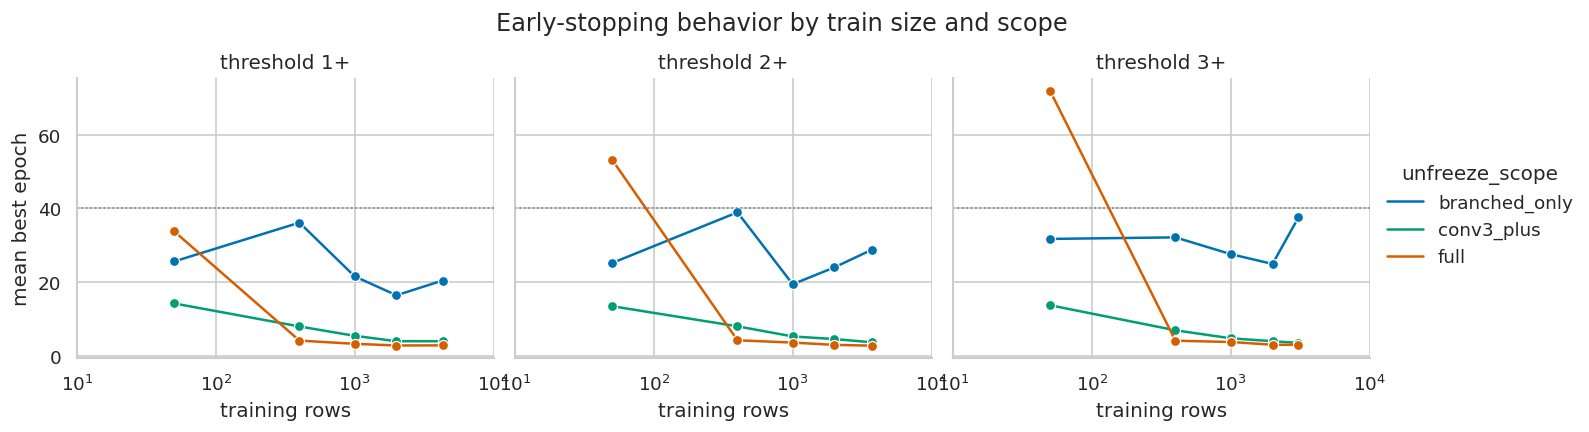

,train_threshold,threshold_label,train_size,unfreeze_scope,best_epoch_mean,best_epoch_std,hit_max_epoch_rate,test_pearson_mean
0,1,1+,50,branched_only,25.625000,16.053748,0.0,0.366161
1,1,1+,50,conv3_plus,14.250000,4.078043,0.0,0.373724
2,1,1+,50,full,33.833333,40.138528,0.0,0.386368
3,1,1+,400,branched_only,36.166667,18.447733,0.0,0.417012
4,1,1+,400,conv3_plus,8.000000,2.919202,0.0,0.409887
5,1,1+,400,full,4.166667,1.274044,0.0,0.403562
6,1,1+,1000,branched_only,21.583333,15.242722,0.0,0.436390
7,1,1+,1000,conv3_plus,5.458333,1.864524,0.0,0.438433
8,1,1+,1000,full,3.291667,1.428869,0.0,0.427684
9,1,1+,2000,branched_only,16.458333,14.046442,0.0,0.448975


In [22]:
epoch_summary = (
    runs.groupby(["train_threshold", "threshold_label", "train_size", "unfreeze_scope"], observed=True)
    .agg(
        best_epoch_mean=("best_epoch", "mean"),
        best_epoch_std=("best_epoch", "std"),
        hit_max_epoch_rate=("best_epoch", lambda s: float((pd.to_numeric(s, errors="coerce") >= example_manifest.get("max_epochs", 250) - 1).mean())),
        test_pearson_mean=("test_pearson", "mean"),
    )
    .reset_index()
)

g = sns.relplot(
    data=epoch_summary,
    x="train_size",
    y="best_epoch_mean",
    hue="unfreeze_scope",
    col="threshold_label",
    kind="line",
    marker="o",
    height=3.4,
    aspect=1.15,
    palette=SCOPE_PALETTE,
    facet_kws={"sharex": False, "sharey": True},
)
for ax in g.axes.flat:
    apply_log10_xaxis(ax, epoch_summary["train_size"])
    ax.axhline(example_manifest.get("patience", 40), color="gray", linestyle=":", linewidth=1.0)
g.set_axis_labels("training rows", "mean best epoch")
g.set_titles("threshold {col_name}")
g.fig.suptitle("Early-stopping behavior by train size and scope", y=1.05)
plt.show()

display(epoch_summary.sort_values(["train_threshold", "train_size", "unfreeze_scope"]))


## Branched-Only No-Early-Stopping Diagnostic

This section loads the follow-up diagnostic run with K562 initialization, `branched_only`, thresholds `1+`, `2+`, `3+`, train sizes `400`, `1000`, and each threshold-specific full pool. Early stopping was disabled, so the run-level CSV still reports the validation-best restored checkpoint, while `learning_curve_histories.csv` shows the full 250-epoch trajectory.


In [23]:
DIAGNOSTIC_RUN_DIR = LC_ROOT / "lib1_enhancer_branched_only_k562_hq8_4seed_noearly_250epoch_may2026"
DIAGNOSTIC_COMBINED_DIR = DIAGNOSTIC_RUN_DIR / "combined"

DIAGNOSTIC_RUNS_PATH = DIAGNOSTIC_COMBINED_DIR / "learning_curve_runs.csv"
DIAGNOSTIC_HISTORIES_PATH = DIAGNOSTIC_COMBINED_DIR / "learning_curve_histories.csv"
DIAGNOSTIC_SUMMARY_PATH = DIAGNOSTIC_COMBINED_DIR / "learning_curve_summary_mean_std.csv"
DIAGNOSTIC_MANIFEST_PATH = DIAGNOSTIC_COMBINED_DIR / "run_manifest_combined.json"


def prepare_diagnostic_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    for col in [
        "seed",
        "epoch",
        "train_threshold",
        "train_size",
        "train_fraction",
        "train_pool_eligible_size",
        "best_epoch",
        "max_epochs_requested",
        "patience_requested",
        "effective_patience",
    ]:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    if "threshold_label" not in frame.columns and "train_threshold" in frame.columns:
        frame["threshold_label"] = frame["train_threshold"].map(
            lambda x: f"{int(x)}+" if pd.notna(x) else "NA"
        )
    if "unfreeze_scope" in frame.columns:
        frame["unfreeze_scope"] = pd.Categorical(frame["unfreeze_scope"], categories=UNFREEZE_SCOPE_ORDER, ordered=True)
    if "init_head" in frame.columns:
        frame["init_head"] = pd.Categorical(frame["init_head"], categories=HEAD_ORDER, ordered=True)
    if "threshold_label" in frame.columns:
        frame["threshold_label"] = pd.Categorical(
            frame["threshold_label"],
            categories=[f"{x}+" for x in THRESHOLD_ORDER],
            ordered=True,
        )
    return frame


diag_runs = prepare_diagnostic_frame(read_csv_required(DIAGNOSTIC_RUNS_PATH))
diag_histories = prepare_diagnostic_frame(read_csv_required(DIAGNOSTIC_HISTORIES_PATH))
diag_summary = prepare_diagnostic_frame(read_csv_required(DIAGNOSTIC_SUMMARY_PATH))
diag_manifest = read_json_required(DIAGNOSTIC_MANIFEST_PATH)
diag_example_manifest = diag_manifest.get("example_manifest", {})

diag_run_long = make_metric_long(diag_runs)
diag_history_long = make_epoch_metric_long(diag_histories)

diag_overview = pd.DataFrame(
    [
        {
            "run_dir": str(DIAGNOSTIC_RUN_DIR),
            "run_rows": len(diag_runs),
            "history_rows": len(diag_histories),
            "seeds": compact_values(diag_runs["seed"]),
            "init_heads": compact_values(diag_runs["init_head"]),
            "unfreeze_scopes": compact_values(diag_runs["unfreeze_scope"]),
            "train_thresholds": compact_values(diag_runs["train_threshold"]),
            "train_sizes": compact_values(diag_runs["train_size"]),
            "max_epochs": compact_values(diag_runs["max_epochs_requested"]),
            "early_stopping_disabled": compact_values(diag_runs["early_stopping_disabled"]),
        }
    ]
)
display(diag_overview)
print("diag_run_long:", diag_run_long.shape)
print("diag_history_long:", diag_history_long.shape)


,run_dir,run_rows,history_rows,seeds,init_heads,unfreeze_scopes,train_thresholds,train_sizes,max_epochs,early_stopping_disabled
0,/home/minhang/synBio_AL/boda2_EU/src/finetune/...,36,9000,"17, 19, 23, 31",K562,branched_only,"1, 2, 3","400, 1000, 3075, 3705, 4295",250,True


diag_run_long: (432, 36)
diag_history_long: (108000, 23)


In [24]:
DIAG_CONFIG_COLS = ["init_head", "unfreeze_scope", "train_threshold", "threshold_label", "train_size"]
DIAG_METRIC_COLS = [
    "train_pearson",
    "val_pearson",
    "test_pearson",
    "train_r2_cod",
    "val_r2_cod",
    "test_r2_cod",
    "train_loss_standardized",
    "val_loss_standardized",
    "test_loss_standardized",
    "best_epoch",
]

diag_perf_aggs = {
    "n_seeds": ("seed", "nunique"),
    "train_pool_eligible_size": ("train_pool_eligible_size", "first"),
    "max_epochs_requested": ("max_epochs_requested", "first"),
    "effective_patience": ("effective_patience", "first"),
}
for col in DIAG_METRIC_COLS:
    if col in diag_runs.columns:
        diag_perf_aggs[f"{col}_mean"] = (col, "mean")
        diag_perf_aggs[f"{col}_se"] = (col, standard_error)

diag_perf_summary = (
    diag_runs.groupby(DIAG_CONFIG_COLS, observed=True)
    .agg(**diag_perf_aggs)
    .reset_index()
    .sort_values(["train_threshold", "train_size"])
)
diag_perf_summary["is_full_pool"] = diag_perf_summary["train_size"] == diag_perf_summary["train_pool_eligible_size"]

display(Markdown("Run-level metrics below are from the restored validation-best checkpoint, not the final epoch."))
display(
    diag_perf_summary[
        [
            "train_threshold",
            "threshold_label",
            "train_size",
            "is_full_pool",
            "n_seeds",
            "best_epoch_mean",
            "train_pearson_mean",
            "val_pearson_mean",
            "test_pearson_mean",
            "train_r2_cod_mean",
            "val_r2_cod_mean",
            "test_r2_cod_mean",
        ]
    ].round(4)
)


Run-level metrics below are from the restored validation-best checkpoint, not the final epoch.

,train_threshold,threshold_label,train_size,is_full_pool,n_seeds,best_epoch_mean,train_pearson_mean,val_pearson_mean,test_pearson_mean,train_r2_cod_mean,val_r2_cod_mean,test_r2_cod_mean
0,1,1+,400,False,4,41.75,0.4463,0.4750,0.4617,0.1961,0.2168,0.2136
1,1,1+,1000,False,4,13.50,0.4050,0.4839,0.4742,0.1629,0.2273,0.2229
2,1,1+,4295,True,4,13.50,0.4124,0.4972,0.5020,0.1694,0.2401,0.2474
3,2,2+,400,False,4,36.50,0.4816,0.4769,0.4935,0.2298,0.2171,0.2371
4,2,2+,1000,False,4,21.00,0.4790,0.4934,0.5024,0.2280,0.2339,0.2487
5,2,2+,3705,True,4,45.25,0.5104,0.5062,0.4931,0.2548,0.2500,0.2397
6,3,3+,400,False,4,26.00,0.4939,0.4678,0.4769,0.2402,0.2131,0.2154
7,3,3+,1000,False,4,36.50,0.5245,0.4933,0.4914,0.2768,0.2330,0.2290
8,3,3+,3075,True,4,35.75,0.4924,0.5025,0.4906,0.2401,0.2414,0.2374


In [25]:
DIAG_EPOCH_KEYS = ["seed", "init_head", "unfreeze_scope", "train_threshold", "threshold_label", "train_size"]


def summarize_noearly_seed_trace(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values("epoch")
    last = group.iloc[-1]
    peak_val = group.loc[pd.to_numeric(group["val_pearson"], errors="coerce").idxmax()]
    peak_test = group.loc[pd.to_numeric(group["test_pearson"], errors="coerce").idxmax()]
    peak_train = group.loc[pd.to_numeric(group["train_pearson"], errors="coerce").idxmax()]
    return pd.Series(
        {
            "final_epoch": float(last["epoch"]),
            "final_train_pearson": float(last["train_pearson"]),
            "final_val_pearson": float(last["val_pearson"]),
            "final_test_pearson": float(last["test_pearson"]),
            "final_train_cod_r2": float(last["train_r2_cod"]),
            "final_val_cod_r2": float(last["val_r2_cod"]),
            "final_test_cod_r2": float(last["test_r2_cod"]),
            "peak_train_pearson": float(peak_train["train_pearson"]),
            "epoch_peak_train_pearson": float(peak_train["epoch"]),
            "peak_val_pearson": float(peak_val["val_pearson"]),
            "epoch_peak_val_pearson": float(peak_val["epoch"]),
            "train_pearson_at_peak_val": float(peak_val["train_pearson"]),
            "test_pearson_at_peak_val": float(peak_val["test_pearson"]),
            "peak_test_pearson": float(peak_test["test_pearson"]),
            "epoch_peak_test_pearson": float(peak_test["epoch"]),
            "final_gap_train_val_pearson": float(last["train_pearson"] - last["val_pearson"]),
            "final_gap_train_test_pearson": float(last["train_pearson"] - last["test_pearson"]),
        }
    )


diag_per_seed_epoch_endpoints = (
    diag_histories.groupby(DIAG_EPOCH_KEYS, observed=True)
    .apply(summarize_noearly_seed_trace)
    .reset_index()
)

endpoint_metric_cols = [col for col in diag_per_seed_epoch_endpoints.columns if col not in DIAG_EPOCH_KEYS]
diag_endpoint_aggs = {"n_seeds": ("seed", "nunique")}
for col in endpoint_metric_cols:
    diag_endpoint_aggs[f"{col}_mean"] = (col, "mean")
    diag_endpoint_aggs[f"{col}_se"] = (col, standard_error)

diag_epoch_endpoint_summary = (
    diag_per_seed_epoch_endpoints.groupby(DIAG_CONFIG_COLS, observed=True)
    .agg(**diag_endpoint_aggs)
    .reset_index()
    .sort_values(["train_threshold", "train_size"])
)

display(Markdown("Final-epoch and peak-epoch summary from the uninterrupted 250-epoch histories."))
display(
    diag_epoch_endpoint_summary[
        [
            "train_threshold",
            "threshold_label",
            "train_size",
            "n_seeds",
            "final_train_pearson_mean",
            "final_val_pearson_mean",
            "final_test_pearson_mean",
            "peak_val_pearson_mean",
            "epoch_peak_val_pearson_mean",
            "test_pearson_at_peak_val_mean",
            "final_gap_train_test_pearson_mean",
            "final_train_cod_r2_mean",
            "final_val_cod_r2_mean",
            "final_test_cod_r2_mean",
        ]
    ].round(4)
)

diag_best_vs_final = diag_runs.merge(
    diag_per_seed_epoch_endpoints[
        DIAG_EPOCH_KEYS
        + [
            "final_train_pearson",
            "final_val_pearson",
            "final_test_pearson",
            "final_gap_train_test_pearson",
        ]
    ],
    on=DIAG_EPOCH_KEYS,
    how="inner",
)
for split in ["train", "val", "test"]:
    diag_best_vs_final[f"delta_final_minus_best_{split}_pearson"] = (
        diag_best_vs_final[f"final_{split}_pearson"] - diag_best_vs_final[f"{split}_pearson"]
    )

diag_best_vs_final_summary = (
    diag_best_vs_final.groupby(DIAG_CONFIG_COLS, observed=True)
    .agg(
        n_seeds=("seed", "nunique"),
        best_epoch_mean=("best_epoch", "mean"),
        best_val_pearson_mean=("val_pearson", "mean"),
        best_test_pearson_mean=("test_pearson", "mean"),
        final_val_pearson_mean=("final_val_pearson", "mean"),
        final_test_pearson_mean=("final_test_pearson", "mean"),
        delta_final_minus_best_val_pearson_mean=("delta_final_minus_best_val_pearson", "mean"),
        delta_final_minus_best_test_pearson_mean=("delta_final_minus_best_test_pearson", "mean"),
        final_gap_train_test_pearson_mean=("final_gap_train_test_pearson", "mean"),
    )
    .reset_index()
    .sort_values(["train_threshold", "train_size"])
)

display(Markdown("Comparison of validation-best restored checkpoint vs final epoch."))
display(diag_best_vs_final_summary.round(4))


Final-epoch and peak-epoch summary from the uninterrupted 250-epoch histories.

,train_threshold,threshold_label,train_size,n_seeds,final_train_pearson_mean,final_val_pearson_mean,final_test_pearson_mean,peak_val_pearson_mean,epoch_peak_val_pearson_mean,test_pearson_at_peak_val_mean,final_gap_train_test_pearson_mean,final_train_cod_r2_mean,final_val_cod_r2_mean,final_test_cod_r2_mean
0,1,1+,400,4,0.8028,0.3188,0.4043,0.4753,42.25,0.4613,0.3986,0.6157,-0.0862,0.0526
1,1,1+,1000,4,0.8804,0.3328,0.3777,0.4850,15.50,0.4822,0.5027,0.7304,-0.0551,0.0176
2,1,1+,4295,4,0.7365,0.4084,0.4091,0.4988,28.00,0.4976,0.3274,0.4862,0.1196,0.1255
3,2,2+,400,4,0.8306,0.3574,0.4013,0.4812,44.00,0.4930,0.4293,0.6573,0.0123,0.0715
4,2,2+,1000,4,0.8778,0.3917,0.3986,0.4961,34.75,0.4931,0.4793,0.7296,0.0307,0.0796
5,2,2+,3705,4,0.7690,0.4387,0.4379,0.5094,47.25,0.4931,0.3310,0.5403,0.1494,0.1604
6,3,3+,400,4,0.8350,0.3329,0.3820,0.4764,59.00,0.4730,0.4531,0.6597,-0.0074,0.0576
7,3,3+,1000,4,0.8794,0.3887,0.4051,0.4955,47.25,0.4898,0.4743,0.7305,0.0565,0.0871
8,3,3+,3075,4,0.7148,0.4399,0.4670,0.5066,46.25,0.4851,0.2479,0.4836,0.1397,0.1919


Comparison of validation-best restored checkpoint vs final epoch.

,init_head,unfreeze_scope,train_threshold,threshold_label,train_size,n_seeds,best_epoch_mean,best_val_pearson_mean,best_test_pearson_mean,final_val_pearson_mean,final_test_pearson_mean,delta_final_minus_best_val_pearson_mean,delta_final_minus_best_test_pearson_mean,final_gap_train_test_pearson_mean
0,K562,branched_only,1,1+,400,4,41.75,0.4750,0.4617,0.3188,0.4043,-0.1563,-0.0574,0.3986
1,K562,branched_only,1,1+,1000,4,13.50,0.4839,0.4742,0.3328,0.3777,-0.1511,-0.0965,0.5027
2,K562,branched_only,1,1+,4295,4,13.50,0.4972,0.5020,0.4084,0.4091,-0.0888,-0.0930,0.3274
3,K562,branched_only,2,2+,400,4,36.50,0.4769,0.4935,0.3574,0.4013,-0.1195,-0.0922,0.4293
4,K562,branched_only,2,2+,1000,4,21.00,0.4934,0.5024,0.3917,0.3986,-0.1016,-0.1038,0.4793
5,K562,branched_only,2,2+,3705,4,45.25,0.5062,0.4931,0.4387,0.4379,-0.0674,-0.0551,0.3310
6,K562,branched_only,3,3+,400,4,26.00,0.4678,0.4769,0.3329,0.3820,-0.1349,-0.0949,0.4531
7,K562,branched_only,3,3+,1000,4,36.50,0.4933,0.4914,0.3887,0.4051,-0.1046,-0.0864,0.4743
8,K562,branched_only,3,3+,3075,4,35.75,0.5025,0.4906,0.4399,0.4670,-0.0626,-0.0236,0.2479


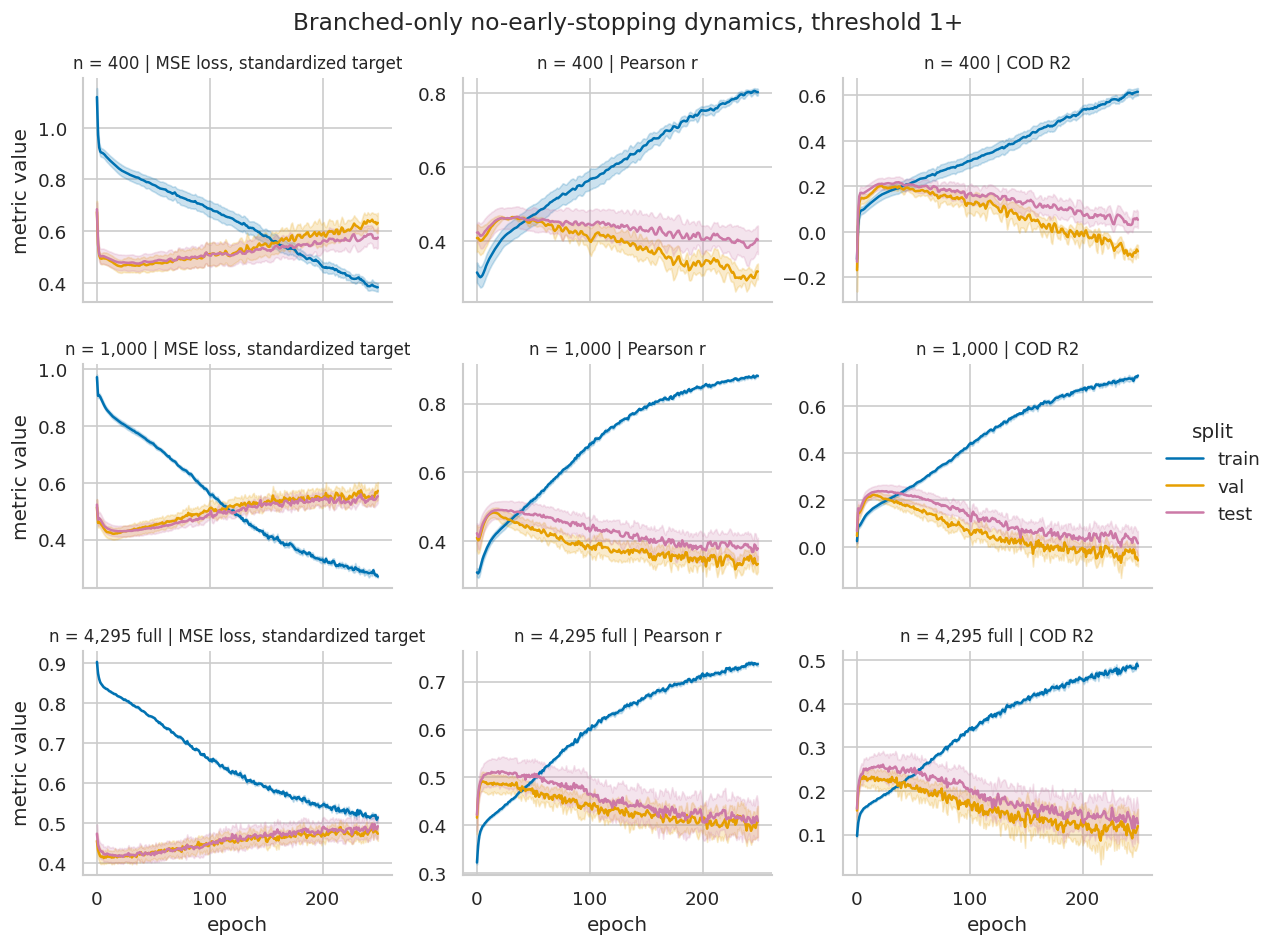

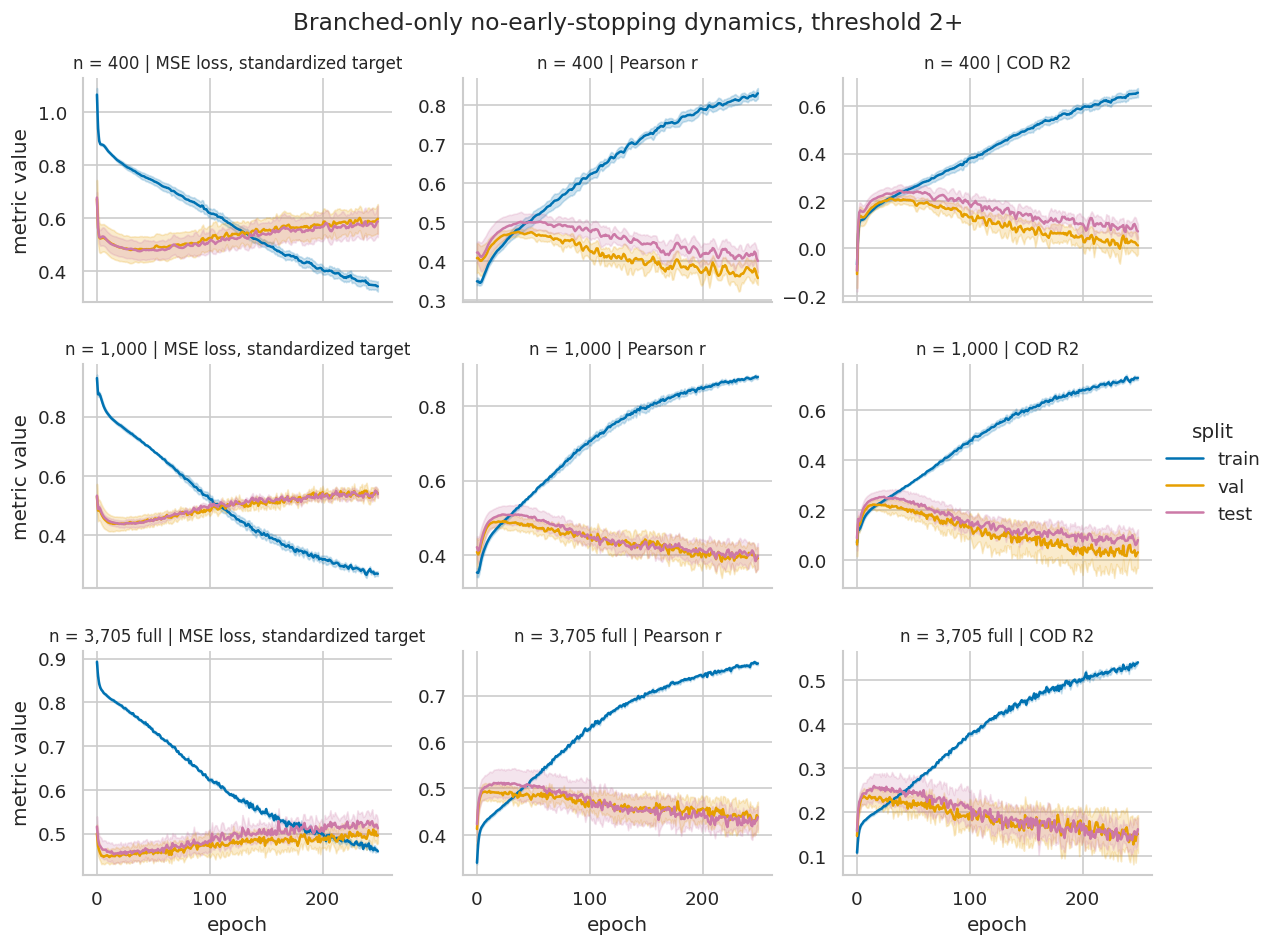

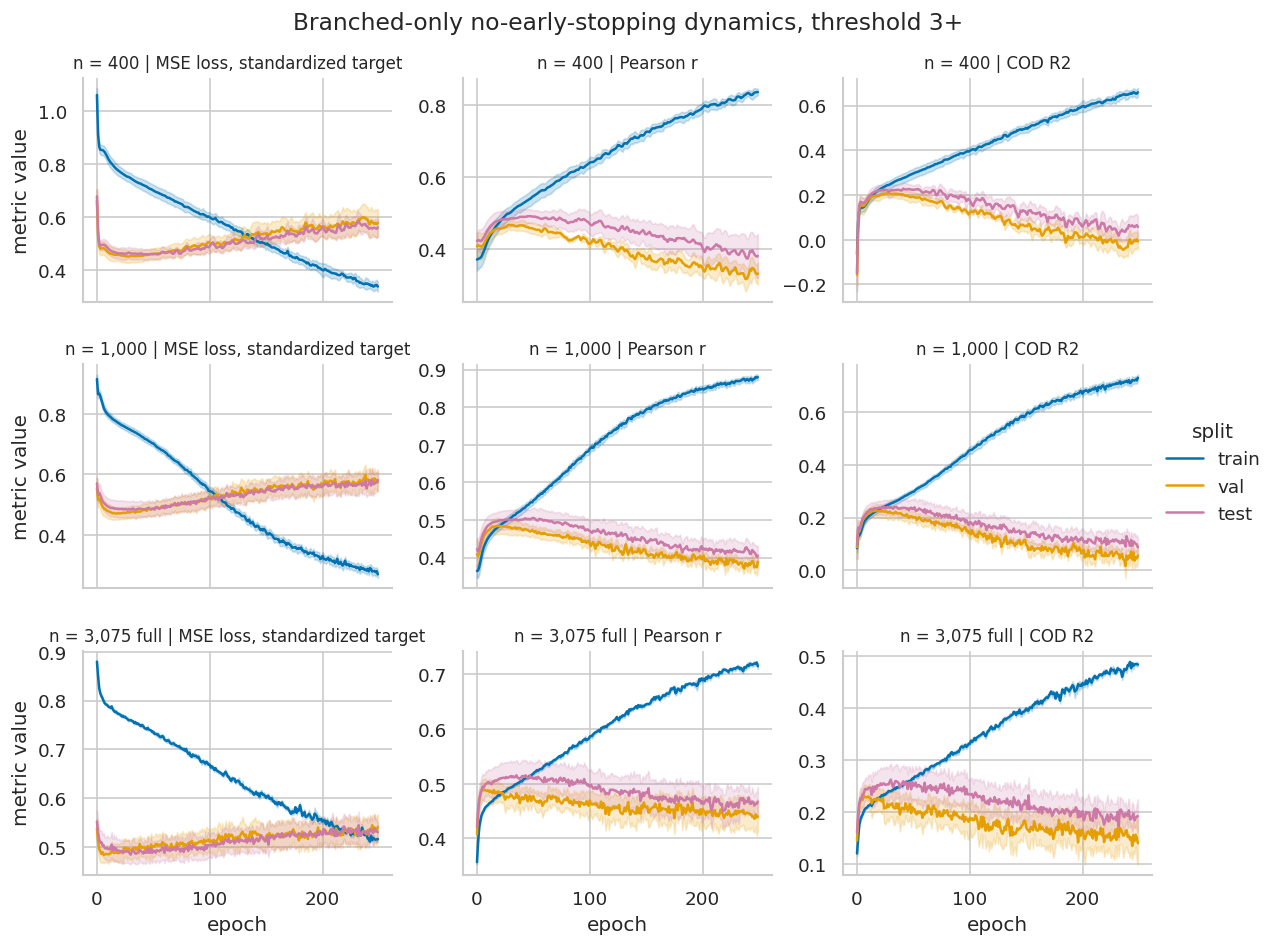

In [26]:
diag_full_train_size_by_threshold = (
    diag_runs.groupby("train_threshold", observed=True)["train_pool_eligible_size"]
    .first()
    .to_dict()
)


def make_diag_train_size_label(row: pd.Series) -> str:
    size = int(row["train_size"])
    threshold = int(row["train_threshold"])
    suffix = " full" if size == int(diag_full_train_size_by_threshold.get(threshold, -1)) else ""
    return f"n = {size:,}{suffix}"


def plot_branched_noearly_epoch_dynamics(
    history_frame: pd.DataFrame = diag_history_long,
    *,
    train_thresholds=(1, 2, 3),
    train_sizes=None,
    metric_roots=("loss", "pearson", "cod_r2"),
    splits=("train", "val", "test"),
    height: float = 2.65,
    aspect: float = 1.24,
):
    """Plot full 250-epoch diagnostic trajectories, one figure per threshold."""
    hist = history_frame.copy()
    hist = _filter_values(hist, "train_threshold", train_thresholds)
    hist = _filter_values(hist, "train_size", train_sizes)
    hist = hist[
        hist["metric_root"].isin(metric_roots)
        & hist["split"].isin(splits)
        & np.isfinite(hist["value"])
    ].copy()
    if hist.empty:
        raise ValueError("No diagnostic history rows matched the requested filters.")

    metric_order = [HISTORY_METRIC_SPECS[k]["label"] for k in metric_roots if k in HISTORY_METRIC_SPECS]
    hist["metric_label"] = pd.Categorical(hist["metric_label"], categories=metric_order, ordered=True)
    hist["split"] = pd.Categorical(hist["split"], categories=[s for s in SPLIT_ORDER if s in splits], ordered=True)
    hist["train_size_label"] = hist.apply(make_diag_train_size_label, axis=1)

    figures = []
    for threshold in _as_list(train_thresholds):
        sub = hist[pd.to_numeric(hist["train_threshold"], errors="coerce") == int(threshold)].copy()
        if sub.empty:
            continue
        size_order = (
            sub[["train_size", "train_size_label"]]
            .drop_duplicates()
            .sort_values("train_size")["train_size_label"]
            .tolist()
        )
        sub["train_size_label"] = pd.Categorical(sub["train_size_label"], categories=size_order, ordered=True)
        g = sns.relplot(
            data=sub,
            x="epoch",
            y="value",
            hue="split",
            row="train_size_label",
            col="metric_label",
            kind="line",
            estimator="mean",
            errorbar="se",
            height=height,
            aspect=aspect,
            palette=SPLIT_PALETTE,
            facet_kws={"sharex": True, "sharey": False},
        )
        g.set_axis_labels("epoch", "metric value")
        g.set_titles(row_template="{row_name}", col_template="{col_name}", size=10)
        g.fig.subplots_adjust(top=0.92, hspace=0.28, wspace=0.23)
        g.fig.suptitle(
            f"Branched-only no-early-stopping dynamics, threshold {int(threshold)}+",
            y=0.99,
            fontsize=14,
        )
        plt.show()
        figures.append(g)
    return figures


diag_noearly_epoch_figures = plot_branched_noearly_epoch_dynamics()


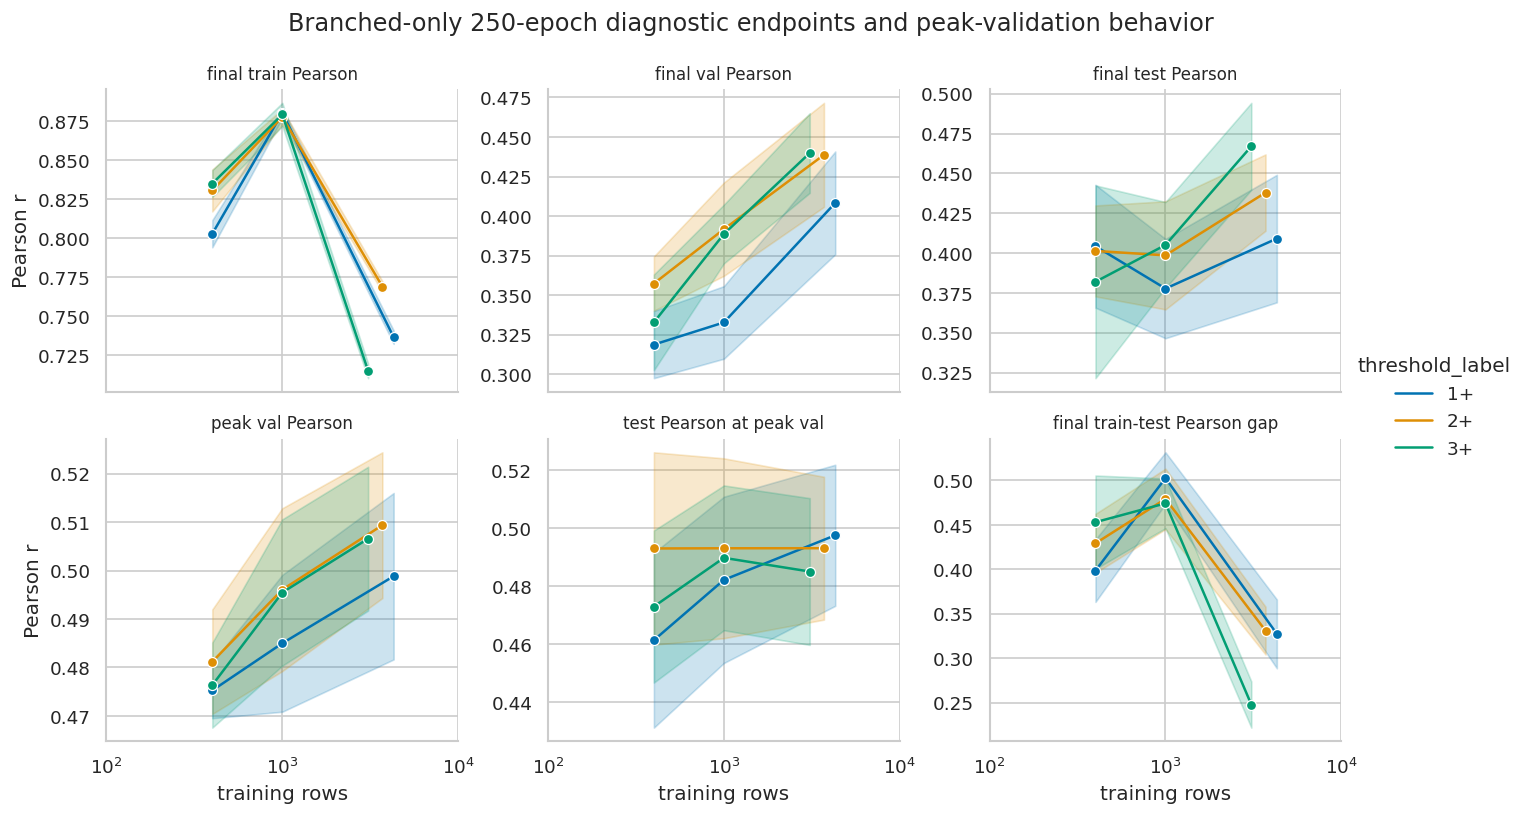

In [27]:
diag_endpoint_plot = diag_per_seed_epoch_endpoints.melt(
    id_vars=DIAG_EPOCH_KEYS,
    value_vars=[
        "final_train_pearson",
        "final_val_pearson",
        "final_test_pearson",
        "peak_val_pearson",
        "test_pearson_at_peak_val",
        "final_gap_train_test_pearson",
    ],
    var_name="quantity",
    value_name="value",
)
quantity_labels = {
    "final_train_pearson": "final train Pearson",
    "final_val_pearson": "final val Pearson",
    "final_test_pearson": "final test Pearson",
    "peak_val_pearson": "peak val Pearson",
    "test_pearson_at_peak_val": "test Pearson at peak val",
    "final_gap_train_test_pearson": "final train-test Pearson gap",
}
diag_endpoint_plot["quantity_label"] = pd.Categorical(
    diag_endpoint_plot["quantity"].map(quantity_labels),
    categories=list(quantity_labels.values()),
    ordered=True,
)
diag_endpoint_plot["threshold_label"] = pd.Categorical(
    diag_endpoint_plot["threshold_label"],
    categories=[f"{x}+" for x in THRESHOLD_ORDER],
    ordered=True,
)

g = sns.relplot(
    data=diag_endpoint_plot,
    x="train_size",
    y="value",
    hue="threshold_label",
    col="quantity_label",
    col_wrap=3,
    kind="line",
    marker="o",
    estimator="mean",
    errorbar="se",
    height=3.25,
    aspect=1.18,
    facet_kws={"sharex": True, "sharey": False},
)
for ax in g.axes.flat:
    apply_log10_xaxis(ax, diag_endpoint_plot["train_size"])
g.set_axis_labels("training rows", "Pearson r")
g.set_titles("{col_name}", size=10)
g.fig.suptitle("Branched-only 250-epoch diagnostic endpoints and peak-validation behavior", y=1.04)
plt.show()


In [28]:
DIAGNOSTIC_ANALYSIS_DIR = DIAGNOSTIC_RUN_DIR / "analysis"
DIAGNOSTIC_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

diag_perf_summary.to_csv(DIAGNOSTIC_ANALYSIS_DIR / "branched_only_noearly_run_level_validation_best_summary.csv", index=False)
diag_per_seed_epoch_endpoints.to_csv(DIAGNOSTIC_ANALYSIS_DIR / "branched_only_noearly_per_seed_epoch_endpoints.csv", index=False)
diag_epoch_endpoint_summary.to_csv(DIAGNOSTIC_ANALYSIS_DIR / "branched_only_noearly_epoch_endpoint_summary.csv", index=False)
diag_best_vs_final_summary.to_csv(DIAGNOSTIC_ANALYSIS_DIR / "branched_only_noearly_best_vs_final_summary.csv", index=False)

print("Wrote diagnostic analysis tables to:", DIAGNOSTIC_ANALYSIS_DIR)


Wrote diagnostic analysis tables to: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_branched_only_k562_hq8_4seed_noearly_250epoch_may2026/analysis


## Trainable Parameters vs Performance

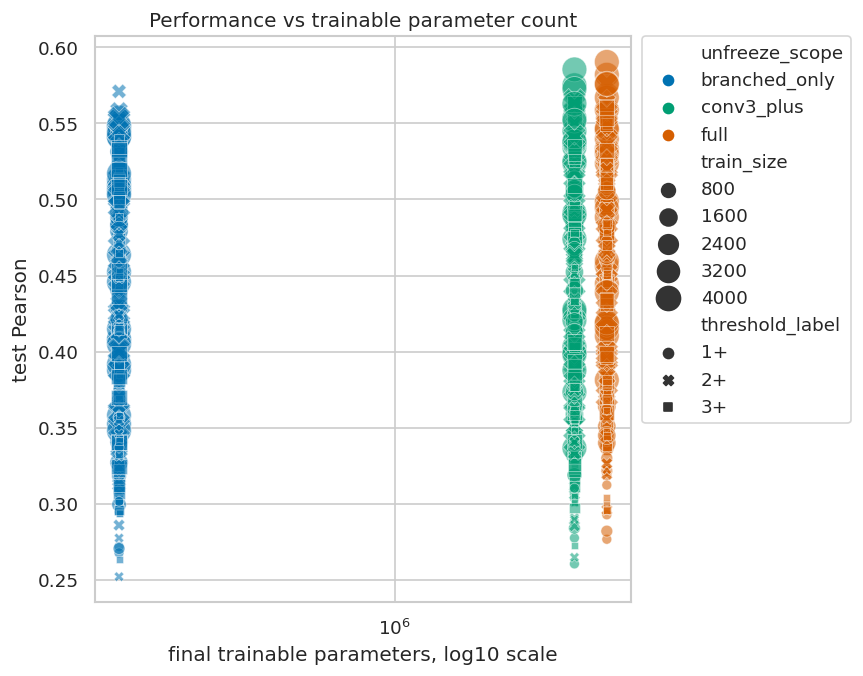

In [29]:
plt.figure(figsize=(9.5, 5.8))
ax = sns.scatterplot(
    data=runs,
    x="final_trainable_params",
    y="test_pearson",
    hue="unfreeze_scope",
    style="threshold_label",
    size="train_size",
    sizes=(35, 220),
    alpha=0.55,
    palette=SCOPE_PALETTE,
)
ax.set_xscale("log")
ax.set_xlabel("final trainable parameters, log10 scale")
ax.set_ylabel("test Pearson")
ax.set_title("Performance vs trainable parameter count")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


## Save Compact Analysis Tables

In [30]:
ANALYSIS_DIR = RUN_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

perf_summary.to_csv(ANALYSIS_DIR / "hpo_config_summary_by_seed_mean.csv", index=False)
mean_val_selected_configs.to_csv(ANALYSIS_DIR / "mean_validation_selected_configs_by_head.csv", index=False)
overall_mean_val_selected_config.to_csv(ANALYSIS_DIR / "overall_mean_validation_selected_config.csv", index=False)
validation_selected_runs.to_csv(ANALYSIS_DIR / "mean_validation_selected_runs_by_seed.csv", index=False)
per_seed_head_selected.to_csv(ANALYSIS_DIR / "diagnostic_per_seed_head_validation_selected_configs.csv", index=False)
per_seed_selection_summary.to_csv(ANALYSIS_DIR / "diagnostic_per_seed_head_validation_selection_summary.csv", index=False)
planned_size_summary.to_csv(ANALYSIS_DIR / "planned_train_size_summary.csv", index=False)

print("Wrote analysis tables to:", ANALYSIS_DIR)


Wrote analysis tables to: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_threshold_hq8_random_mixed_b2_allheads_8seed_absgrid_may2026/analysis


## Notes to Carry Into Discussion

- Use validation-selected summaries for model-choice claims; use test-selected rankings only as diagnostics.
- Compare thresholds at matched sizes (`50`, `400`, `1000`, `2000`) separately from full-pool endpoints because each threshold has a different maximum train-pool size.
- If the validation-selected winner changes by init head, report that as head sensitivity rather than collapsing too early.
- The random HQ val/test split varies by seed, so seed variance includes both training stochasticity and heldout-split sampling variance.
